# EDA

## Setup

In [1]:
!./venv/bin/pip3 install matplotlib numpy scikit-learn seaborn pandas kaggle statsmodels

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached statsmodels-0.14.6-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.5 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached python_slugify-8.0.4-py2.py3-none-any.whl.metadata (8.5 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached pyyaml-6.0.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (2.4 kB

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

### Read the Dataset

In [4]:
df = pd.read_csv("data.csv")

In [5]:
df.describe()

,Age,NS1,IgG,IgM,Fever_Duration,Body_Temperature,Platelet_Count,WBC_Count,Headache,Retro_Orbital_Pain,Myalgia,Rash,Outcome
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,998.000000,999.000000,1000.000000,1000.000000,1000.000000,990.000000,1000.000000
mean,35.924000,0.519000,0.533000,0.475000,3.023000,38.182600,151884.377756,4698.756757,0.553000,0.392000,0.457000,0.379798,0.533000
std,16.468437,0.499889,0.499159,0.499624,2.439349,1.253279,90494.246848,2111.970898,0.497432,0.488441,0.498397,0.485582,0.499159
min,8.000000,0.000000,0.000000,0.000000,0.000000,36.000000,26885.000000,1740.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,0.000000,1.000000,36.900000,70992.750000,2857.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,1.000000,1.000000,0.000000,3.000000,38.700000,96207.500000,3506.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,50.000000,1.000000,1.000000,1.000000,5.000000,39.300000,239724.250000,6673.500000,1.000000,1.000000,1.000000,1.000000,1.000000
max,65.000000,1.000000,1.000000,1.000000,7.000000,40.600000,362426.000000,10229.000000,1.000000,1.000000,1.000000,1.000000,1.000000


I checked the biological ranges for Platelet and WBC values to ensure that they are in the plausible biological range.

min Platelet_Count is a hallmark of acute dengue known as thrombocytopenia (critically low platelets). Not too many patients have this value (as it can be seen in kdeplot), no further investigation.
max Platelet_Count is still considered normal for a healthy human

Similarly, WBC counts are normal in the context of this dataset.

In [165]:
df.sample(5)

,Gender,Age,NS1,IgG,IgM,Area,AreaType,HouseType,District,Fever_Duration,Body_Temperature,Platelet_Count,WBC_Count,Joint_Pain,Headache,Retro_Orbital_Pain,Myalgia,Rash,Outcome
343,Female,59,1,1,0,Bosila,Developed,Building,Dhaka,6,38.9,69609.0,3464.0,Severe,0,1,1,1.0,1
310,Female,48,1,1,0,Mohammadpur,Undeveloped,Other,Dhaka,3,39.5,69894.0,2762.0,Severe,1,0,0,1.0,1
118,Male,37,1,1,0,Jatrabari,Undeveloped,Tinshed,Dhaka,3,39.0,97680.0,3155.0,Moderate,1,1,1,0.0,1
412,Female,54,0,0,1,Khilgaon,Undeveloped,Other,Dhaka,0,36.9,215438.0,5798.0,NaN,1,0,0,0.0,0
149,Male,17,0,0,0,Khilkhet,Developed,Building,Dhaka,0,36.8,221093.0,6604.0,NaN,0,0,0,0.0,0


### Checking for null values

Looks like half of `Joint_Pain` values are NaN. I will try to impute these values and see if that improves the result. Imputing the other features should also be done, but that is a much easier job.

In [12]:
null_values = df.isnull().sum()
null_values[null_values > 0]


AreaType            2
Platelet_Count      2
WBC_Count           1
Joint_Pain        491
Rash               10
dtype: int64

In [95]:
df[df['Rash'].isnull() | df['Platelet_Count'].isnull() | df['WBC_Count'].isnull() | df['AreaType'].isnull()]

,Gender,Age,NS1,IgG,IgM,Area,AreaType,HouseType,District,Fever_Duration,Body_Temperature,Platelet_Count,WBC_Count,Joint_Pain,Headache,Retro_Orbital_Pain,Myalgia,Rash,Outcome
45,Female,13,0,0,0,Banasree,NaN,Tinshed,Dhaka,1,36.4,265005.0,7380.0,NaN,0,0,0,0.0,0
46,Male,62,0,1,0,Sabujbagh,Undeveloped,Tinshed,Dhaka,4,39.6,NaN,2659.0,Severe,1,1,1,1.0,1
123,Male,17,0,0,0,Mohammadpur,Developed,Other,Dhaka,0,36.2,258762.0,6958.0,NaN,1,0,0,NaN,0
124,Female,56,0,0,0,Kadamtali,Undeveloped,Tinshed,Dhaka,2,36.8,258933.0,3826.0,NaN,1,0,0,NaN,0
125,Male,54,0,0,0,Ramna,Developed,Other,Dhaka,0,36.6,209086.0,7173.0,NaN,0,0,0,NaN,0
303,Female,30,0,0,0,Dhanmondi,NaN,Building,Dhaka,0,36.5,295902.0,8040.0,NaN,0,0,0,0.0,0
753,Female,43,1,1,1,Dhanmondi,Developed,Other,Dhaka,5,39.0,70577.0,NaN,Moderate,0,1,1,0.0,1
763,Male,42,1,1,1,Gulshan,Developed,Building,Dhaka,7,39.2,64838.0,2532.0,Moderate,0,1,1,NaN,1
874,Female,8,0,0,0,Rampura,Undeveloped,Other,Dhaka,0,37.0,191565.0,7001.0,NaN,0,0,0,NaN,0
877,Female,56,1,1,1,Kamrangirchar,Developed,Building,Dhaka,4,39.1,64144.0,3196.0,Severe,1,0,1,NaN,1


### Checking for Duplicates

No exact duplicates found

In [92]:
df.duplicated().sum()

np.int64(0)

No near-duplicates, using KDTree that created k-dimensional points of data entries and then measures distances between points.

Top 5 most similar rows by Minkowski/Euclidean distance did not look similar enough to be considered duplicates

In [183]:
from scipy.spatial import KDTree

kd_df = df[df.notna().all(axis=1)].copy()
kd_df = pd.get_dummies(
    kd_df,
    columns=["AreaType", "HouseType", "Joint_Pain", "Gender"],
    drop_first=True,
    dtype=int
)

raw_kd_df = kd_df.copy()
cols_to_match = kd_df.drop(columns=["Area", "District"]).columns

df_0 = raw_kd_df[raw_kd_df["Outcome"] == 0].copy()
df_1 = raw_kd_df[raw_kd_df["Outcome"] == 1].copy()

scaler = StandardScaler()
scaler.fit(raw_kd_df[cols_to_match])

df_0_scaled = pd.DataFrame(
    scaler.transform(df_0[cols_to_match]),
    columns=cols_to_match,
    index=df_0.index,
)
df_1_scaled = pd.DataFrame(
    scaler.transform(df_1[cols_to_match]),
    columns=cols_to_match,
    index=df_1.index,
)

# 2. Build the tree for the '1' group on scaled data
tree = KDTree(df_1_scaled[cols_to_match].to_numpy())

# 3. For every row in df_0, find the nearest neighbor in df_1
distances, indices = tree.query(df_0_scaled[cols_to_match].to_numpy(), k=1)

top_n = min(5, len(distances))
top_n_idx_in_df_0 = np.argsort(distances)[:top_n]

pairs = []
for rank, idx_in_df_0 in enumerate(top_n_idx_in_df_0, start=1):
    idx_in_df_1 = int(indices[idx_in_df_0])

    row0_scaled = df_0_scaled.iloc[[idx_in_df_0]][cols_to_match].to_numpy()
    row1_scaled = df_1_scaled.iloc[[idx_in_df_1]][cols_to_match].to_numpy()

    row0_orig = pd.Series(
        scaler.inverse_transform(row0_scaled)[0],
        index=cols_to_match,
    )
    row1_orig = pd.Series(
        scaler.inverse_transform(row1_scaled)[0],
        index=cols_to_match,
    )

    pair_df = pd.DataFrame({"row0": row0_orig, "row1": row1_orig}).T
    pairs.append(pair_df)

top_pairs_df = pd.concat(
    pairs,
    keys=[
        f"pair_{rank} | dist={distances[idx_in_df_0]:.4f}"
        for rank, idx_in_df_0 in enumerate(top_n_idx_in_df_0, start=1)
    ],
    names=["pair", "row"],
)

top_pairs_df

Age  NS1  IgG  IgM  Fever_Duration  \
pair                 row                                         
pair_1 | dist=7.6084 row0  40.0  0.0  0.0  0.0             2.0   
                     row1  58.0  0.0  1.0  0.0             3.0   
pair_2 | dist=7.9056 row0  47.0  0.0  0.0  0.0             1.0   
                     row1  58.0  0.0  1.0  0.0             3.0   
pair_3 | dist=7.9831 row0  46.0  0.0  0.0  0.0             0.0   
                     row1  58.0  0.0  1.0  0.0             3.0   
pair_4 | dist=8.0432 row0  45.0  0.0  0.0  0.0             0.0   
                     row1  58.0  0.0  1.0  0.0             3.0   
pair_5 | dist=8.1347 row0  50.0  0.0  0.0  1.0             0.0   
                     row1  50.0  1.0  1.0  1.0             3.0   

                           Body_Temperature  Platelet_Count  WBC_Count  \
pair                 row                                                 
pair_1 | dist=7.6084 row0              37.2        244675.0     4775.0   
                     row1              38.9         76611.0     3259.0   
pair_2 | dist=7.9056 row0              37.0        252196.0     5773.0   
                     row1              38.9         76611.0     3259.0   
pair_3 | dist=7.9831 row0              37.1        202431.0     6021.0   
                     row1              38.9         76611.0     3259.0   
pair_4 | dist=8.0432 row0              37.1        234375.0     6702.0   
                     row1              38.9         76611.0     3259.0   
pair_5 | dist=8.1347 row0              37.0        117931.0     6619.0   
                     row1              39.8         85292.0     3039.0   

                           Headache  Retro_Orbital_Pain  Myalgia  Rash  \
pair                 row                                                 
pair_1 | dist=7.6084 row0       0.0                 0.0      0.0   0.0   
                     row1       1.0                 1.0      1.0   0.0   
pair_2 | dist=7.9056 row0       1.0                 0.0      0.0   0.0   
                     row1       1.0                 1.0      1.0   0.0   
pair_3 | dist=7.9831 row0       0.0                 0.0      0.0   0.0   
                     row1       1.0                 1.0      1.0   0.0   
pair_4 | dist=8.0432 row0       1.0                 0.0      1.0   1.0   
                     row1       1.0                 1.0      1.0   0.0   
pair_5 | dist=8.1347 row0       0.0                 0.0      0.0   0.0   
                     row1       0.0                 0.0      0.0   0.0   

                           Outcome  AreaType_Undeveloped  HouseType_Other  \
pair                 row                                                    
pair_1 | dist=7.6084 row0      0.0                   1.0              0.0   
                     row1      1.0                   1.0              0.0   
pair_2 | dist=7.9056 row0      0.0                   1.0              0.0   
                     row1      1.0                   1.0              0.0   
pair_3 | dist=7.9831 row0      0.0                   1.0              0.0   
                     row1      1.0                   1.0              0.0   
pair_4 | dist=8.0432 row0      0.0                   1.0              0.0   
                     row1      1.0                   1.0              0.0   
pair_5 | dist=8.1347 row0      0.0                   0.0              0.0   
                     row1      1.0                   0.0              0.0   

                           HouseType_Tinshed  Joint_Pain_Severe  Gender_Male  
pair                 row                                                      
pair_1 | dist=7.6084 row0                1.0                0.0          1.0  
                     row1                1.0                0.0          1.0  
pair_2 | dist=7.9056 row0                0.0                0.0          1.0  
                     row1                1.0                0.0          1.0  
pair_3 | dist=7.9831 row0                1.0              

### Area Values Distribution

Area value counts are quite even, which is odd, considering that areas have different population, income status, healthcare availability, denge outbreaks etc. Either the dataset is well-curated to avoid any type of bias (which might be bad in this case), or it was synthetically, randomly or AI generated.

In [17]:
df["Area"].value_counts()

Area
Jatrabari              38
Demra                  38
Mirpur                 34
Dhanmondi              34
Bangshal               34
Kadamtali              34
New Market             33
Keraniganj             33
Paltan                 31
Badda                  31
Sutrapur               31
Tejgaon                31
Biman Bandar           30
Ramna                  30
Khilkhet               30
Rampura                30
Banasree               29
Mohammadpur            28
Gulshan                28
Motijheel              27
Kalabagan              27
Kafrul                 26
Kamrangirchar          26
Hazaribagh             25
Shahbagh               24
Bosila                 24
Sher-e-Bangla Nagar    23
Pallabi                23
Sabujbagh              23
Khilgaon               23
Chawkbazar             22
Gendaria               22
Adabor                 22
Cantonment             20
Shyampur               19
Lalbagh                17
Name: count, dtype: int64

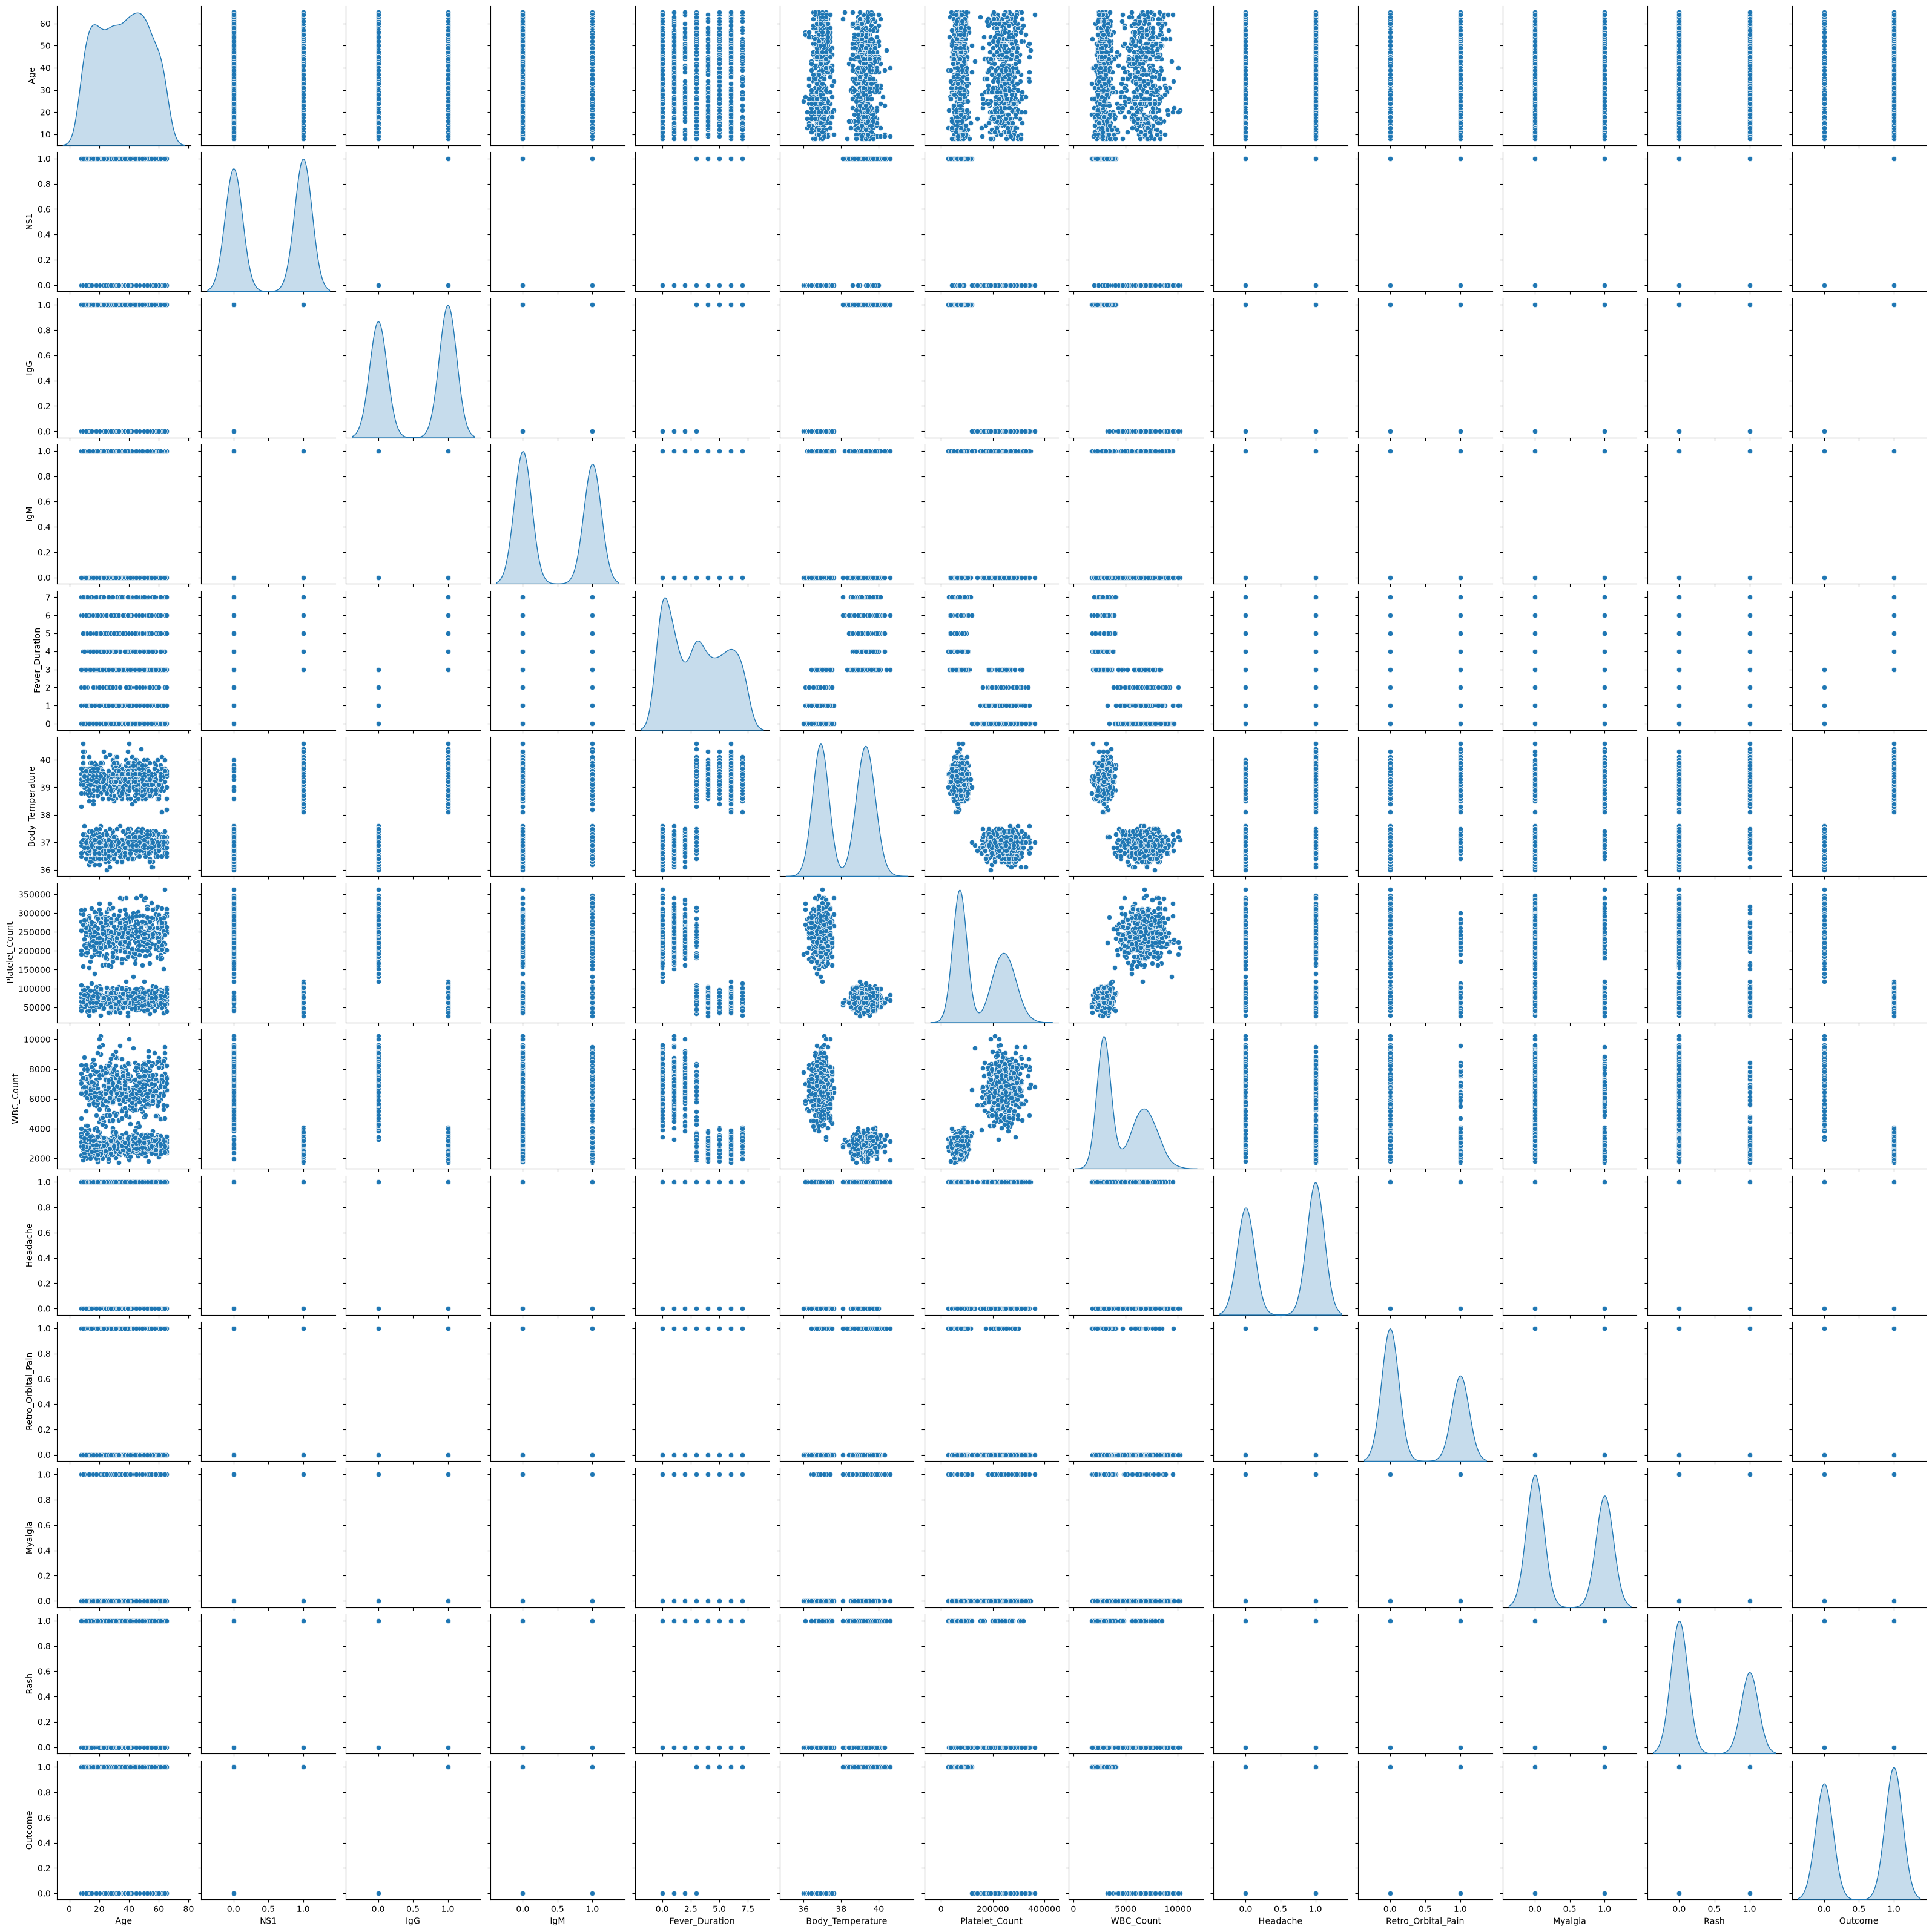

In [8]:
sns.pairplot(data=df, diag_kind='kde')

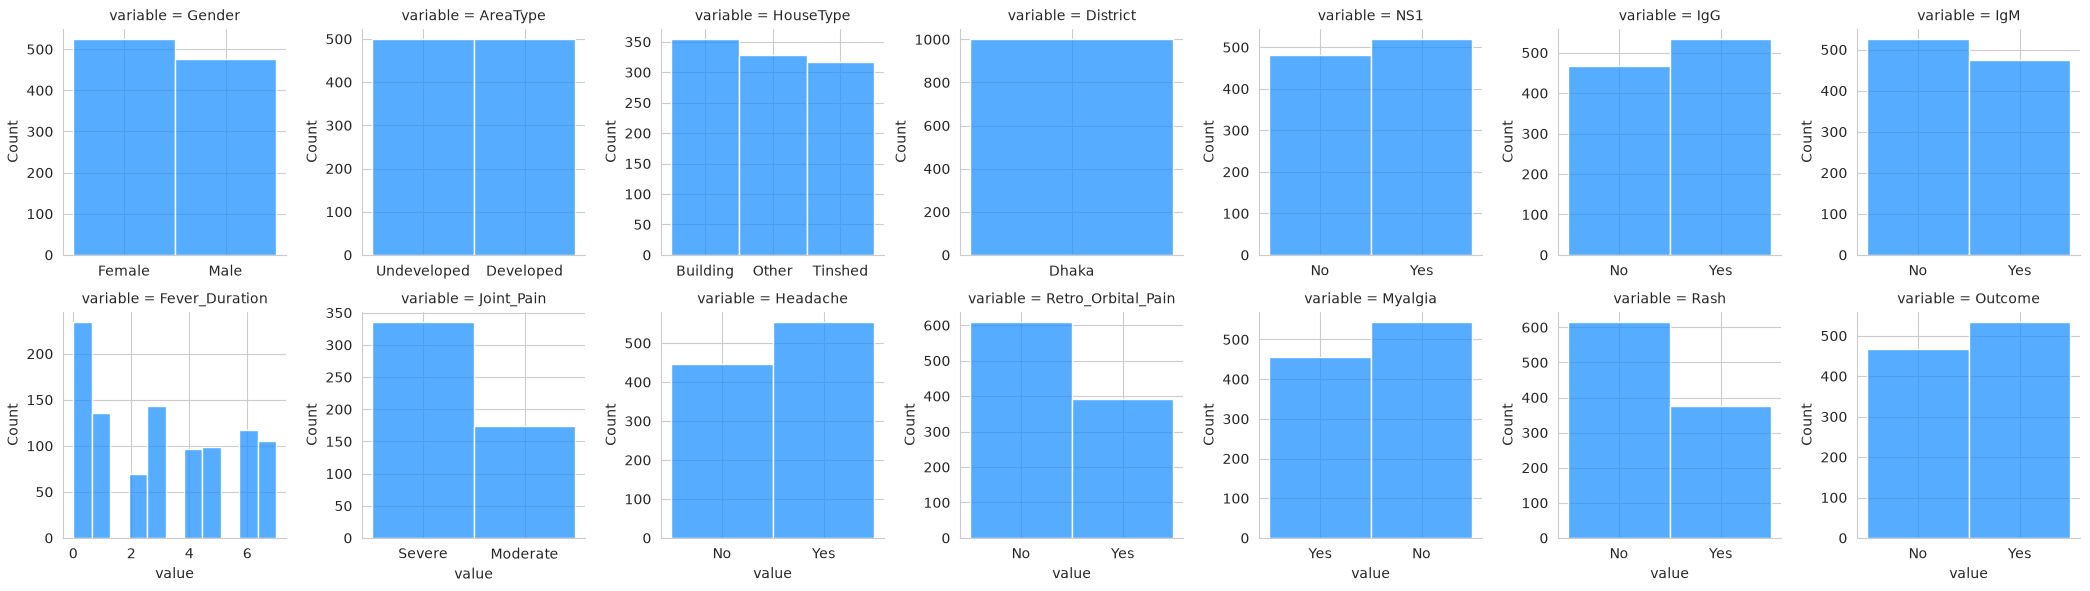

In [6]:
count_cols = ["Gender", "AreaType", "HouseType", "District", "NS1", "IgG", "IgM", "Fever_Duration", "Joint_Pain", "Headache", "Retro_Orbital_Pain", "Myalgia", "Rash", "Outcome"]
kde_cols = ["Age", "Body_Temperature", "Platelet_Count", "WBC_Count"]

with sns.axes_style('whitegrid'):
  plot_cols = [
      "NS1", "IgG", "IgM", "Headache",
      "Retro_Orbital_Pain", "Myalgia", "Rash", "Outcome"
  ]

  plot_df = df.copy()
  plot_df[plot_cols] = plot_df[plot_cols].replace({0: "No", 1: "Yes"})
  nd = pd.melt(plot_df, value_vars=count_cols)
  n1 = sns.FacetGrid(nd, col='variable', col_wrap=7, sharex=False, sharey=False)
  n1 = n1.map(sns.histplot, 'value', color='#1e90ff')

Though females dominate the dataset, it is statistically more likely that males contract dengue, because they complete more work outside during the day (the time when dengue-carrying mosquitos are the most active), and they are more likely to address to the doctor because 

1: men are more likely to postpone treating the disease until the symptoms are very evident and 

2. because in poor countries they are the main providers to the family, so their well-being is essential to their family's finances.

Source: https://pubmed.ncbi.nlm.nih.gov/23908884/

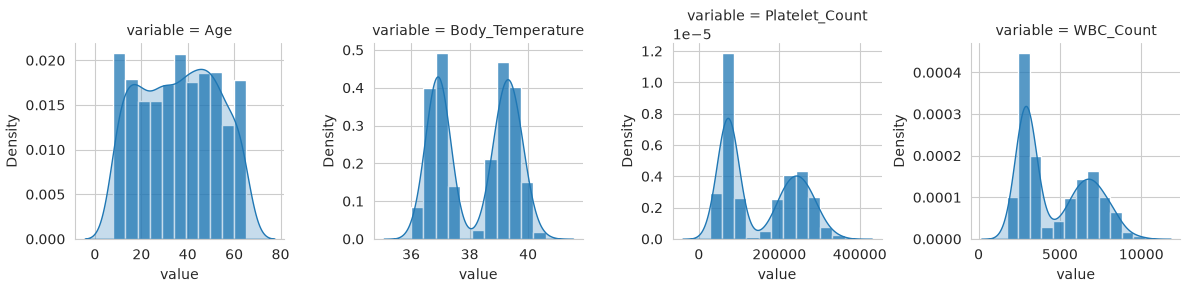

In [28]:
with sns.axes_style('whitegrid'):
  nd = pd.melt(df, value_vars=kde_cols)
  n1 = sns.FacetGrid(nd, col='variable', col_wrap=4, sharex=False, sharey=False)

  n1.map(
      sns.histplot,
      'value',
      stat='density',
  )

  n1.map(
      sns.kdeplot,
      'value',
      fill=True
  )

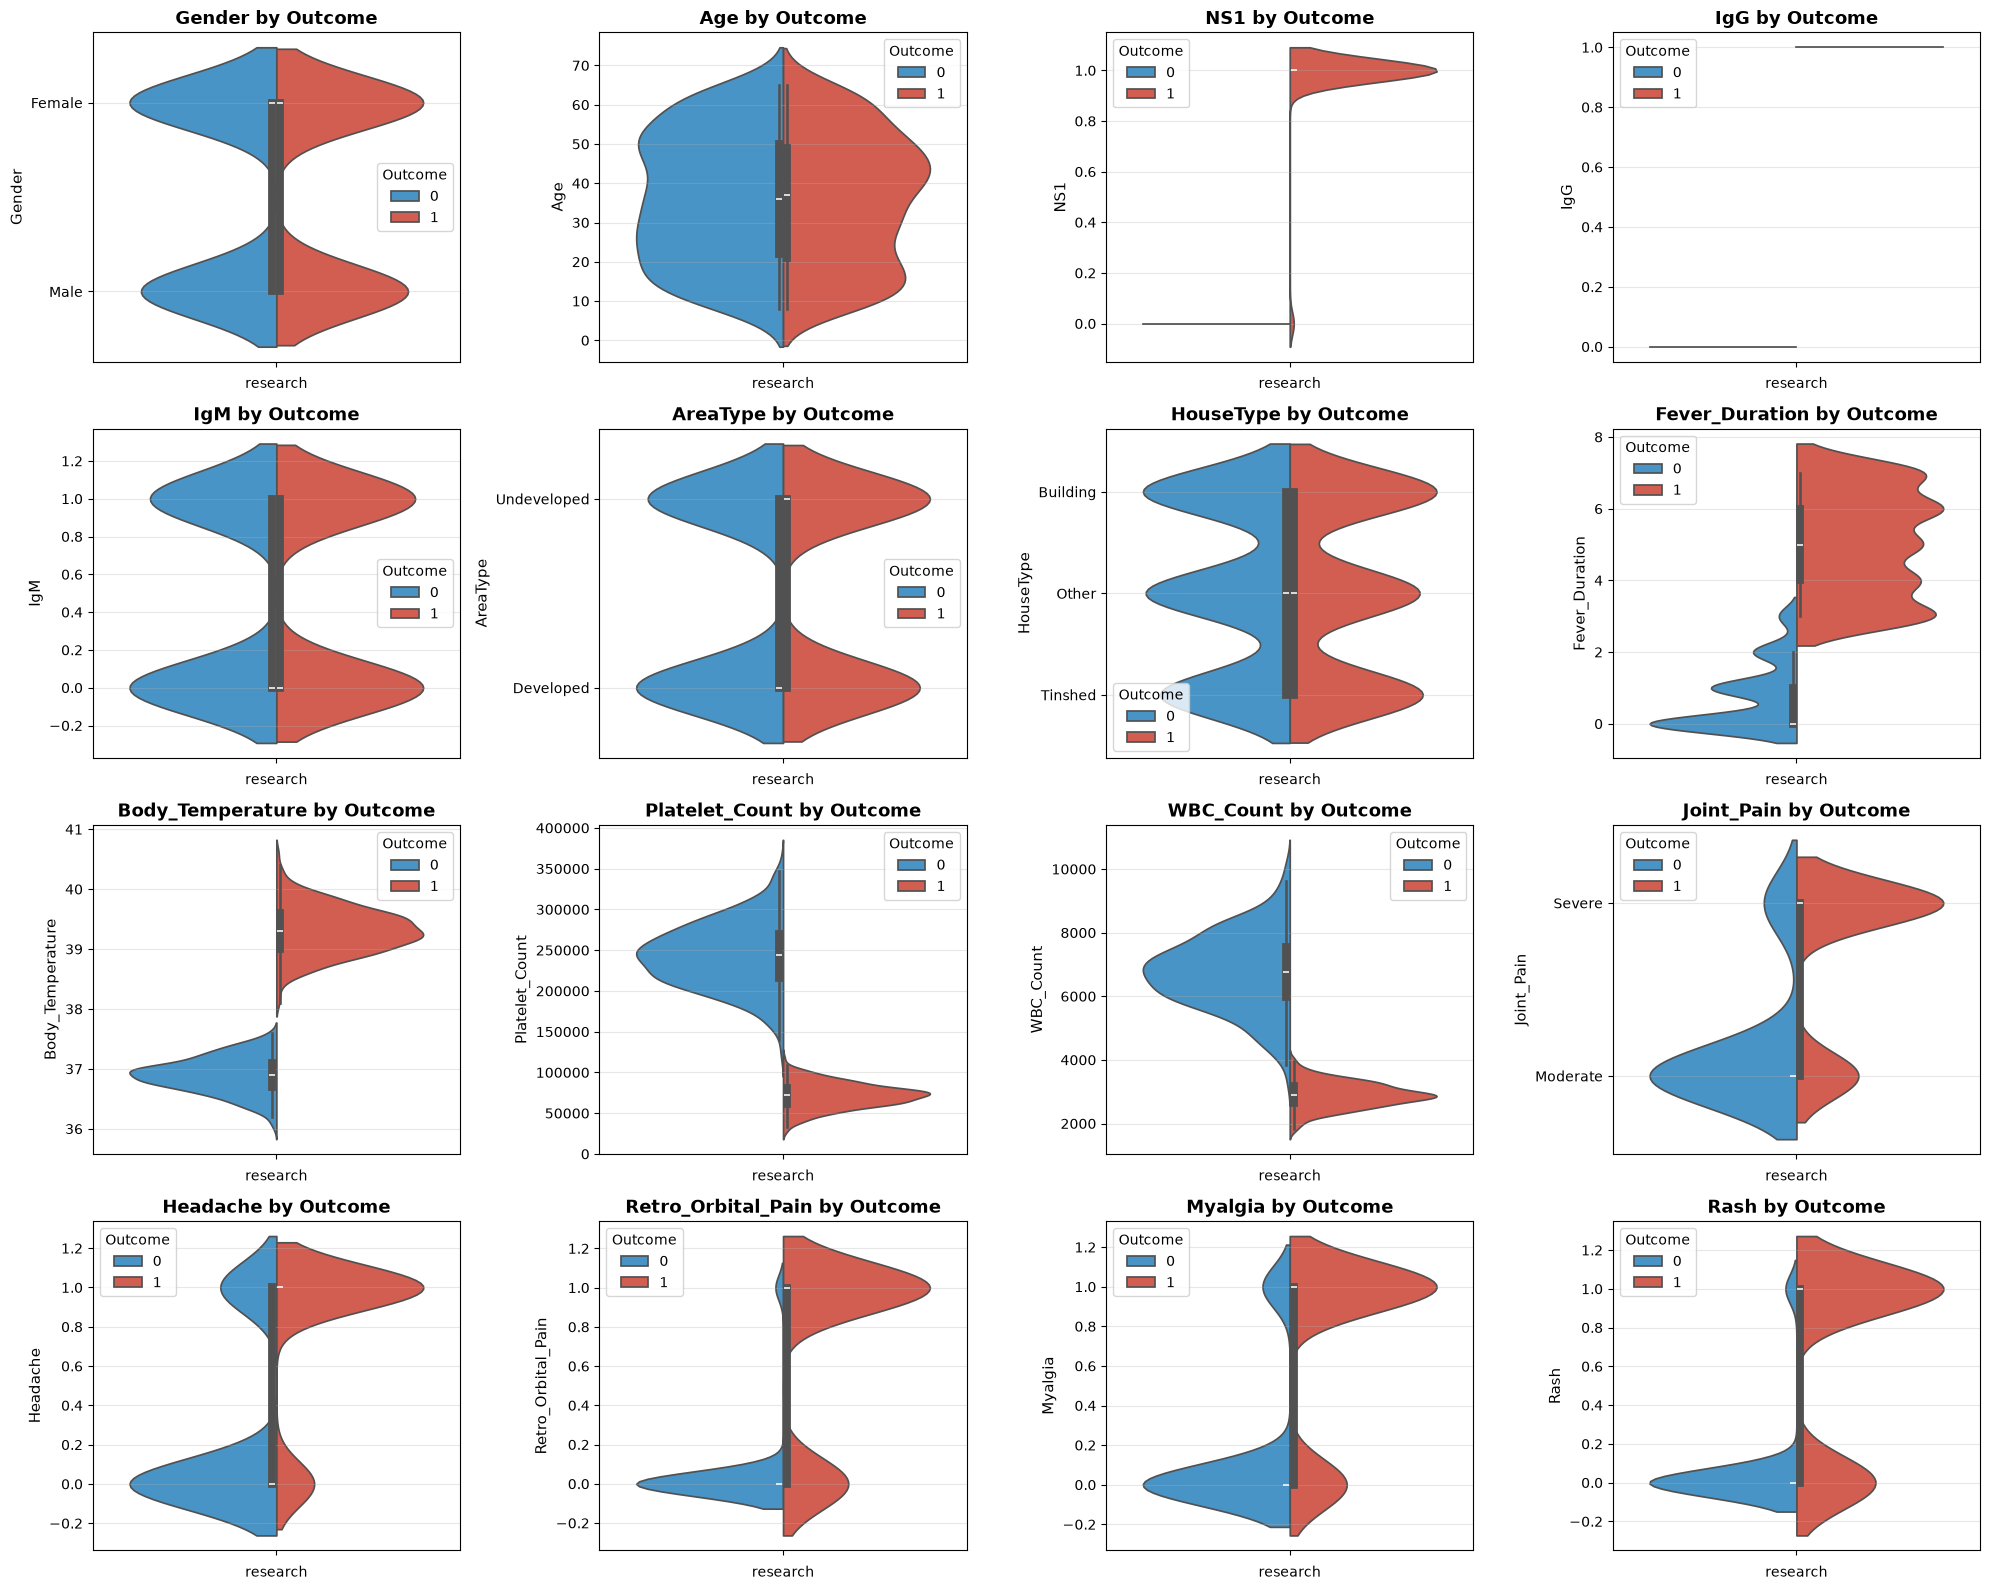

In [72]:
violin_cols = df.drop(columns=["Outcome", "District", "Area"])
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.ravel()

for idx, feature in enumerate(violin_cols):
    sns.violinplot(data=df, hue='Outcome', y=feature,
                   palette={0: '#3498db', 1: '#e74c3c'}, 
                   split=True, inner='box', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Outcome', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(feature, fontsize=11)
    axes[idx].set_xlabel('research')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

`AreaType` having no correlation to `Outcome` is a very strange finding. Dengue predominantly spreads in areas with high poverty count, so those underdeveloped areas are more susceptible to dengue disease. The fact that there is almost zero correlation seen is very strange.

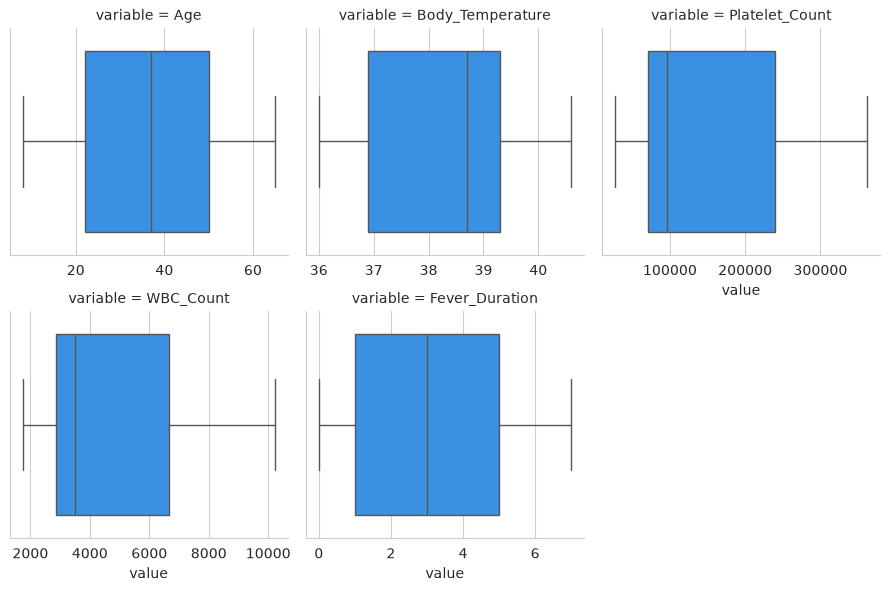

In [38]:
box_plot_cols = pd.Series(kde_cols + ["Fever_Duration"])

with sns.axes_style('whitegrid'):
  nd = pd.melt(df, value_vars=box_plot_cols)
  n1 = sns.FacetGrid(nd, col='variable', col_wrap=3, sharex=False, sharey=False)

  n1.map_dataframe(
      sns.boxplot,
      x="value",
      orient="h",
      color="#1e90ff"
  )

In [26]:
df.sample(5)

,Gender,Age,NS1,IgG,IgM,Area,AreaType,HouseType,District,Fever_Duration,Body_Temperature,Platelet_Count,WBC_Count,Joint_Pain,Headache,Retro_Orbital_Pain,Myalgia,Rash,Outcome
458,Female,13,0,0,0,Kalabagan,Undeveloped,Tinshed,Dhaka,1,36.6,266241.0,6835.0,NaN,1,0,0,0.0,0
495,Female,21,1,1,0,Keraniganj,Developed,Other,Dhaka,3,39.3,84744.0,2759.0,Severe,1,1,1,1.0,1
486,Male,13,0,0,1,Gendaria,Undeveloped,Tinshed,Dhaka,1,36.2,284751.0,7005.0,NaN,1,0,0,0.0,0
606,Male,65,1,1,0,Jatrabari,Undeveloped,Other,Dhaka,6,39.0,59047.0,2454.0,Severe,1,1,0,1.0,1
460,Female,50,0,0,0,Biman Bandar,Undeveloped,Tinshed,Dhaka,0,37.3,292262.0,6824.0,NaN,0,0,0,0.0,0


<Axes: >

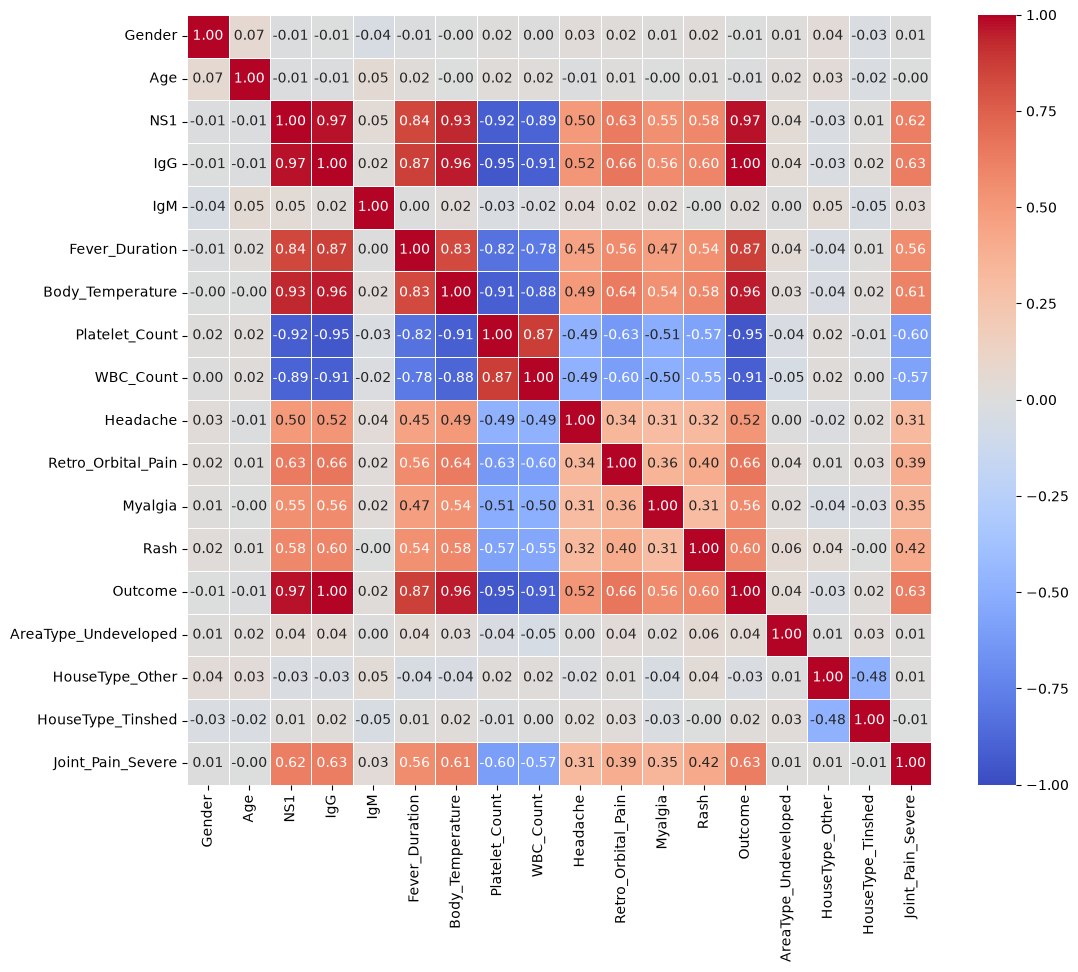

In [ ]:
def create_corr(df: pd.DataFrame) -> pd.DataFrame:
    corr_df = df.drop(columns=["Area", "District"])
    corr_df = pd.get_dummies(corr_df, columns=["AreaType", "HouseType", "Joint_Pain"], drop_first=True, dtype=int)
    corr_df["Gender"] = corr_df["Gender"].map({"Male": 1, "Female": 0})

    return corr_df.corr()

corr_df = create_corr(df)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

In [39]:
# find rows with different IgG and Outcome values
df[df["IgG"] != df["Outcome"]]

,Gender,Age,NS1,IgG,IgM,Area,AreaType,HouseType,District,Fever_Duration,Body_Temperature,Platelet_Count,WBC_Count,Joint_Pain,Headache,Retro_Orbital_Pain,Myalgia,Rash,Outcome


In [51]:
print("Number of rows where IgG and Outcome are different:", df[df["IgG"] != df["Outcome"]].shape[0], "out of", df.shape[0])
print("Number of rows where NS1 and Outcome are different:", df[df["NS1"] != df["Outcome"]].shape[0], "out of", df.shape[0])

Number of rows where IgG and Outcome are different: 0 out of 1000
Number of rows where NS1 and Outcome are different: 14 out of 1000


# Notes
Problem with dataset:
- Potential for a big portion of false positives. Having immunoglobulines in blood (`IgG = 1`) does not necessarily mean that the patient has dengue. All diseases have specialized IgG cells in blood. Same for `IgM` and `Body_Temperature`. Ideally, the model should specifically indicate dengue, not any other disease, to minimize false positives.

- Missing intervals in feature values. For example, `Body_temperature` has barely any values for temperature around 38 degrees, which is a totally reasonable value to have. Same for `Platelet_Count` and `WBC_Count`. 


Technical Goal:
- Balance the features to avoid missing intervals in data (e.g. ~38 degress for `Body_Temperature`). For most of the features with such characteristic, there is a significant lack of values on the decision boundary between positive and negative outcome. An appropriate imputation method has to be chosen that can handle generating new dataset entries specifically on the boundary between the classes.

- Get rid of columns that have data leakage from `Outcome` column
    - NS1 (protein that is synthesized in the blood as a reaction to dengue. Very rare false positives, very specific to dengue)
    - IgG (indicates whether or not the patient had dengue for 14 days - ~years. Though does not specifically indicate dengue, the dataset is structured in such a way that when `IgG = 1`, it always means that the patient has dengue.)
    - IgM (indicates whether the patient has been recently infected 3-7 days. Again, non-specific to dengue, can indicate a number of diseases).

Business Goal:
- Identify which features are *causing* the outcome, and which features are a *consequence* of the outcome (e.g. `Area` can causate the outcome, but `Joint_Pain` is a consequence of dengue). This will allow to create educated generalizations/stereotypes of the type of patients that are more or less likely to have dengue.

- For the poor city of Dhaka, try to provide maximum impact by training the model on features that do not require clinical inspection. By not requiring the model to know `NS1`, `IgG` and other clinical metrics, the solution can become much more scalable and provide help for the portion of Dhaka population that does not have easy accessibility to diagnosis.



Without data leakage cols

In [90]:
dl_df = df.drop(columns=["IgG", "IgM", "NS1", "WBC_Count", "Platelet_Count"])

<Axes: >

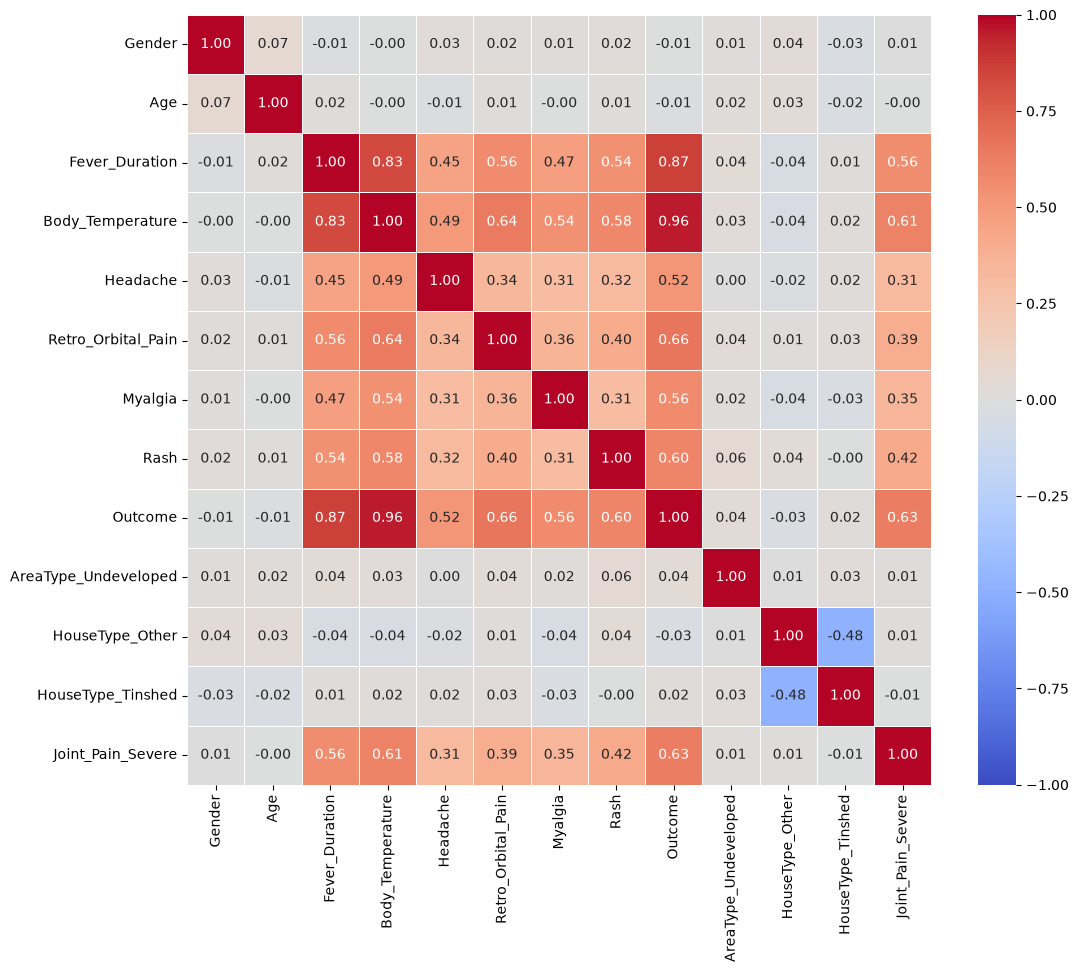

In [91]:
dl_df_corr = create_corr(dl_df)
plt.figure(figsize=(12, 10))
sns.heatmap(dl_df_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

In [21]:
def compare_features(df: pd.DataFrame, feature1: str, feature2: str) -> None:
    svm_model = make_pipeline(
        IterativeImputer(n_nearest_features=5),
        StandardScaler(),
        SVC(kernel="linear", C=1.0)
    )

    X = df[[feature1, feature2]]
    y = df["Outcome"]
    svm_model.fit(X, y)

    # Create a grid in the original feature space
    x_min, x_max = X[feature1].min(), X[feature1].max()
    y_min, y_max = X[feature2].min(), X[feature2].max()

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = pd.DataFrame({
        feature1: xx.ravel(),
        feature2: yy.ravel()
    })

    decision_values = svm_model.decision_function(grid).reshape(xx.shape)

    # Plot observations and the SVM decision boundary
    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x=feature1,
        y=feature2,
        hue="Outcome",
        palette={0: "blue", 1: "red"},
        alpha=0.7
    )

    plt.contour(
        xx, yy, decision_values,
        levels=[0],
        colors="black",
        linewidths=2
    )

    plt.contourf(
        xx, yy, decision_values,
        levels=[-np.inf, 0, np.inf],
        colors=["#0000FF", "#FF0000"],
        alpha=0.08
    )

    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.title("Linear Separability in Dengue Diagnosis")
    plt.grid(alpha=0.3)
    plt.show()

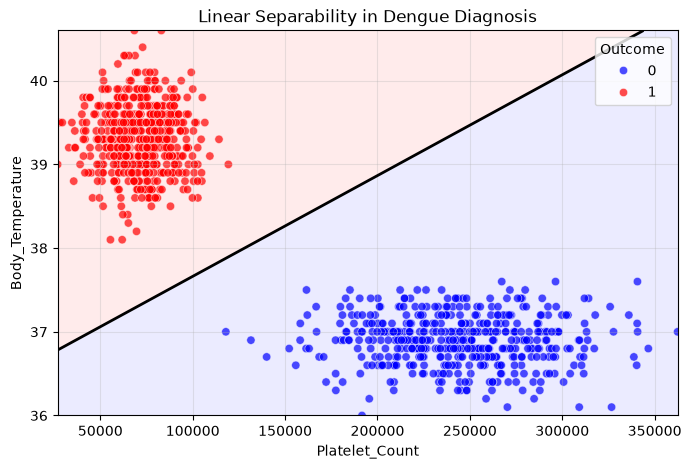

In [22]:
# Fit a linear SVM on the two features
feature_columns = ["Platelet_Count", "Body_Temperature"]
compare_features(df, *feature_columns)

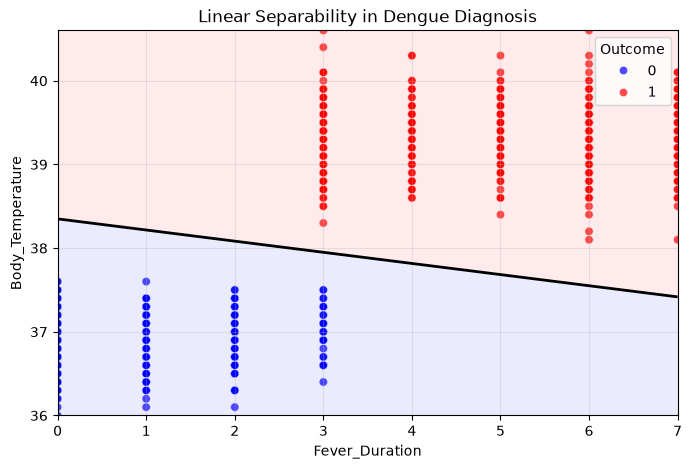

In [23]:
# Fit a linear SVM on the two features
feature_columns = ["Fever_Duration", "Body_Temperature"]
compare_features(df, *feature_columns)

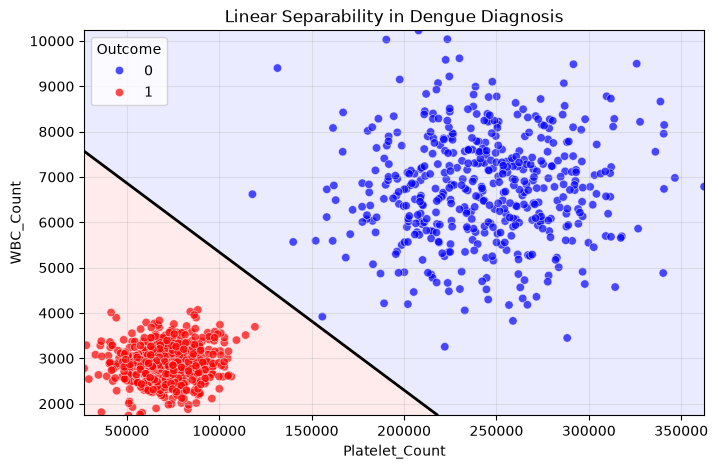

In [24]:
# Fit a linear SVM on the two features
feature_columns = ["Platelet_Count", "WBC_Count"]
compare_features(df, *feature_columns)

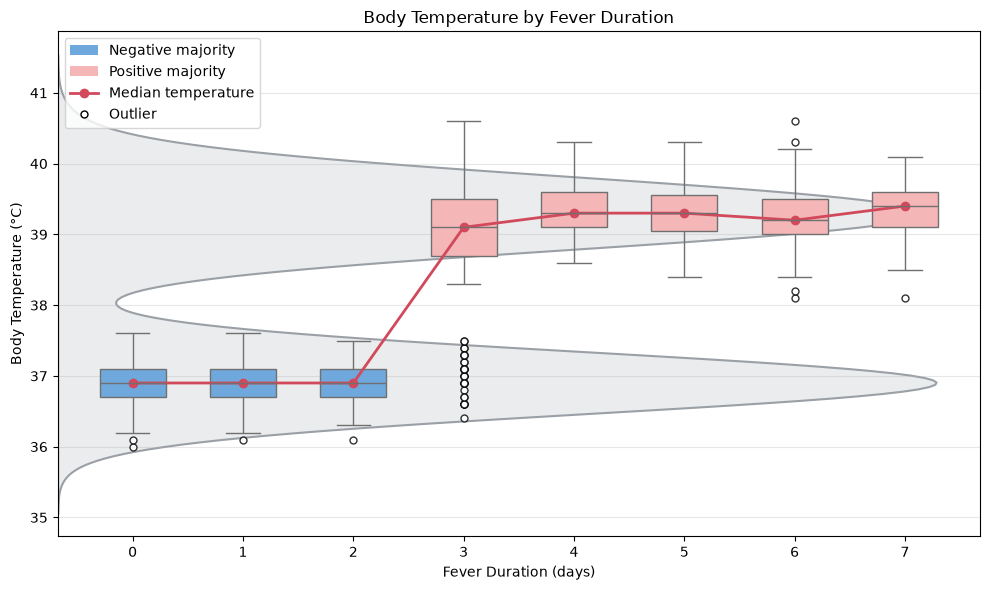

In [52]:
connected_box_df = df[["Fever_Duration", "Body_Temperature", "Outcome"]].dropna().copy()
connected_box_df["Fever_Duration"] = connected_box_df["Fever_Duration"].astype(int)
connected_box_df = connected_box_df.sort_values("Fever_Duration")

fever_days = sorted(connected_box_df["Fever_Duration"].unique())
median_temperature = (
    connected_box_df.groupby("Fever_Duration")["Body_Temperature"]
    .median()
    .reindex(fever_days)
)
outcome_majority = (
    connected_box_df.groupby("Fever_Duration")["Outcome"]
    .mean()
    .reindex(fever_days)
)

negative_color = "#6fa8dc"
positive_color = "#f4b6b6"
box_colors = [
    negative_color if majority < 0.5 else positive_color
    for majority in outcome_majority
]

fig, ax = plt.subplots(figsize=(10, 6))

kde_ax = ax.twiny()
sns.kdeplot(
    data=connected_box_df,
    y="Body_Temperature",
    fill=True,
    color="#9aa0a6",
    alpha=0.2,
    linewidth=1.5,
    ax=kde_ax
)
kde_ax.set_zorder(0)
kde_ax.set_xticks([])
kde_ax.set_xlabel("")
kde_ax.set_ylabel("")
kde_ax.patch.set_alpha(0)
for spine in kde_ax.spines.values():
    spine.set_visible(False)
ax.set_zorder(1)
ax.patch.set_alpha(0)

sns.boxplot(
    data=connected_box_df,
    x="Fever_Duration",
    y="Body_Temperature",
    order=fever_days,
    color="#8ecae6",
    width=0.6,
    showfliers=True,
    flierprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 5,
        "alpha": 0.8
    },
    ax=ax
)

for box, box_color in zip(ax.patches, box_colors):
    box.set_facecolor(box_color)

ax.plot(
    range(len(fever_days)),
    median_temperature.values,
    color="#d1495b",
    marker="o",
    linewidth=2
)

legend_handles = [
    Patch(facecolor=negative_color, label="Negative majority"),
    Patch(facecolor=positive_color, label="Positive majority"),
    Line2D([0], [0], color="#d1495b", marker="o", linewidth=2, label="Median temperature"),
    Line2D([0], [0], marker="o", markerfacecolor="white", markeredgecolor="black", color="black", linestyle="None", markersize=5, label="Outlier")
]
ax.legend(handles=legend_handles)
ax.set_title("Body Temperature by Fever Duration")
ax.set_xlabel("Fever Duration (days)")
ax.set_ylabel("Body Temperature (°C)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

An interesting counter-intuitive observation: the fact that in the first 3 days the patient did not have fever does not mean that the fever wont be developed soon. The initial phase of dengue does not have fever and usually develops after day 3. However, other symptoms can indicate dengue before the fever kicks in.

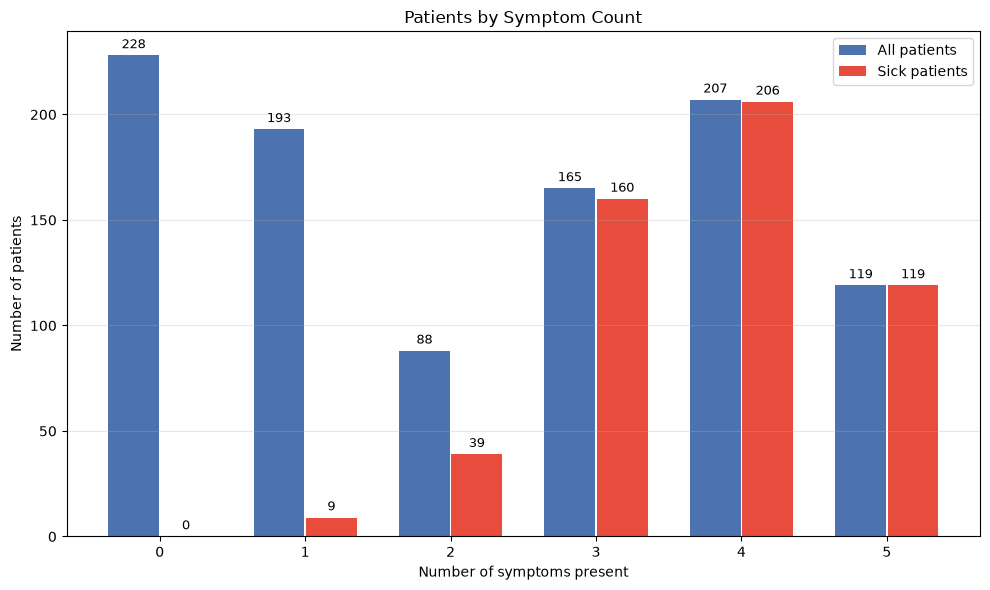

In [91]:
joint_pain_present = df["Joint_Pain"].notna().astype(int).rename("Joint_Pain")

symptom_cols = [
    "Joint_Pain",
    "Headache",
    "Retro_Orbital_Pain",
    "Myalgia",
    "Rash",
]

symptom_values = pd.concat(
    [
        joint_pain_present,
        df[["Headache", "Retro_Orbital_Pain", "Myalgia", "Rash"]],
    ],
    axis=1,
)

symptom_count = symptom_values[symptom_cols].eq(1).sum(axis=1)

symptom_distribution = (
    symptom_count.value_counts()
    .reindex(range(len(symptom_cols) + 1), fill_value=0)
    .rename_axis("number_of_symptoms")
    .reset_index(name="patient_count")
)

sick_by_symptom_count = (
    pd.DataFrame({"n_symptoms": symptom_count, "Outcome": df["Outcome"]})
    .loc[lambda d: d["Outcome"] == 1]
    .groupby("n_symptoms")
    .size()
    .reindex(range(len(symptom_cols) + 1), fill_value=0)
    .rename_axis("number_of_symptoms")
    .reset_index(name="sick_patient_count")
)

x = np.arange(len(symptom_cols) + 1)
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - 0.18, symptom_distribution["patient_count"], width=0.35, color="#4c72b0", label="All patients")
ax.bar(x + 0.18, sick_by_symptom_count["sick_patient_count"], width=0.35, color="#e74c3c", label="Sick patients")

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

ax.set_title("Patients by Symptom Count")
ax.set_xlabel("Number of symptoms present")
ax.set_ylabel("Number of patients")
ax.set_xticks(x)
ax.set_xticklabels(range(len(symptom_cols) + 1))
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [96]:
joint_pain_present = df["Joint_Pain"].notna().astype(int).rename("Joint_Pain")

symptom_cols = [
    "Joint_Pain",
    "Headache",
    "Retro_Orbital_Pain",
    "Myalgia",
    "Rash"
]

symptom_values = pd.concat(
    [
        joint_pain_present,
        df[["Headache", "Retro_Orbital_Pain", "Myalgia", "Rash"]]
    ],
    axis=1
)

symptoms_present = symptom_values[symptom_cols].eq(1).apply(
    lambda row: ", ".join(row.index[row].tolist()) or "None",
    axis=1
)
n_symptoms = symptom_values[symptom_cols].eq(1).sum(axis=1)

symptom_combinations_df = (
    pd.DataFrame({
        "n_symptoms": n_symptoms,
        "symptoms_present": symptoms_present,
        "Outcome": df["Outcome"]
    })
    .groupby(["n_symptoms", "symptoms_present"])
    .agg(
        row_count=("Outcome", "size"),
        positive_cases=("Outcome", lambda outcomes: (outcomes == 1).sum()),
        negative_cases=("Outcome", lambda outcomes: (outcomes == 0).sum())
    )
    .reset_index()
    .sort_values(["n_symptoms", "row_count"], ascending=[True, False])
    .reset_index(drop=True)
)

symptom_combinations_df


,n_symptoms,symptoms_present,row_count,positive_cases,negative_cases
0,0,None,228,0,228
1,1,Headache,90,2,88
2,1,Myalgia,42,1,41
3,1,Joint_Pain,31,5,26
4,1,Rash,16,1,15
5,1,Retro_Orbital_Pain,14,0,14
6,2,"Headache, Myalgia",21,3,18
7,2,"Joint_Pain, Headache",16,8,8
8,2,"Joint_Pain, Myalgia",11,5,6
9,2,"Headache, Retro_Orbital_Pain",9,6,3


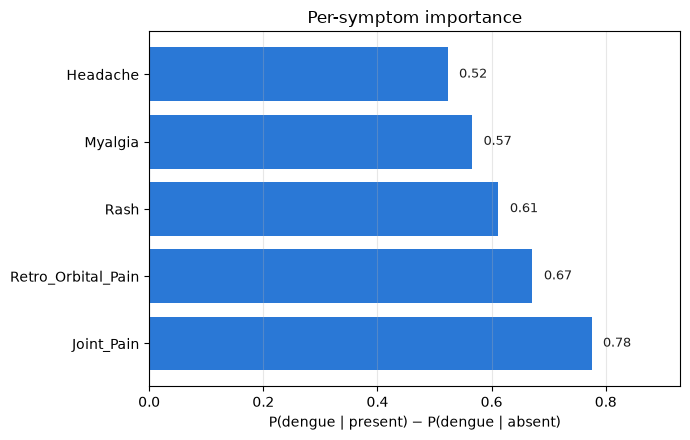

In [92]:
def plot_symptom_importance(df: pd.DataFrame, ax=None, figsize=(7, 4.5)):
    joint_pain_present = df["Joint_Pain"].notna().astype(int).rename("Joint_Pain")
    symptom_cols = ["Joint_Pain", "Headache", "Retro_Orbital_Pain", "Myalgia", "Rash"]

    symptom_values = pd.concat(
        [joint_pain_present, df[["Headache", "Retro_Orbital_Pain", "Myalgia", "Rash"]]],
        axis=1,
    )

    symptoms_present = symptom_values[symptom_cols].eq(1).apply(
        lambda row: ", ".join(row.index[row].tolist()) or "None",
        axis=1,
    )
    n_symptoms = symptom_values[symptom_cols].eq(1).sum(axis=1)

    symptom_df = (
        pd.DataFrame({"n_symptoms": n_symptoms, "symptoms_present": symptoms_present, "Outcome": df["Outcome"]})
        .groupby(["n_symptoms", "symptoms_present"])
        .agg(row_count=("Outcome", "size"), positive_cases=("Outcome", lambda s: (s == 1).sum()))
        .reset_index()
    )

    symptom_df["positive_rate"] = symptom_df["positive_cases"] / symptom_df["row_count"]
    symptom_df["members"] = symptom_df["symptoms_present"].apply(
        lambda s: [] if s == "None" else [x.strip() for x in s.split(",")]
    )

    rows = []
    for symptom in sorted({m for members in symptom_df["members"] for m in members}):
        mask = symptom_df["members"].apply(lambda members: symptom in members)
        p_present = symptom_df.loc[mask, "positive_cases"].sum() / symptom_df.loc[mask, "row_count"].sum()
        p_absent = symptom_df.loc[~mask, "positive_cases"].sum() / symptom_df.loc[~mask, "row_count"].sum()
        rows.append((symptom, p_present - p_absent))

    lift_df = pd.DataFrame(rows, columns=["symptom", "lift"]).sort_values("lift", ascending=False)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    bars = ax.barh(lift_df["symptom"], lift_df["lift"], color="#2a78d6")
    for bar, value in zip(bars, lift_df["lift"]):
        ax.text(
            value + 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            ha="left",
            fontsize=9,
            color="#1f1f1f",
        )
    ax.set_title("Per-symptom importance")
    ax.set_xlabel("P(dengue | present) − P(dengue | absent)")
    ax.set_xlim(0, max(0.8, lift_df["lift"].max() * 1.2))
    ax.grid(axis="x", alpha=0.3)
    return ax


fig, ax = plt.subplots(figsize=(7, 4.5))
plot_symptom_importance(df, ax=ax)
plt.tight_layout()
plt.show()


contamination by area type, area type vs dataset avg

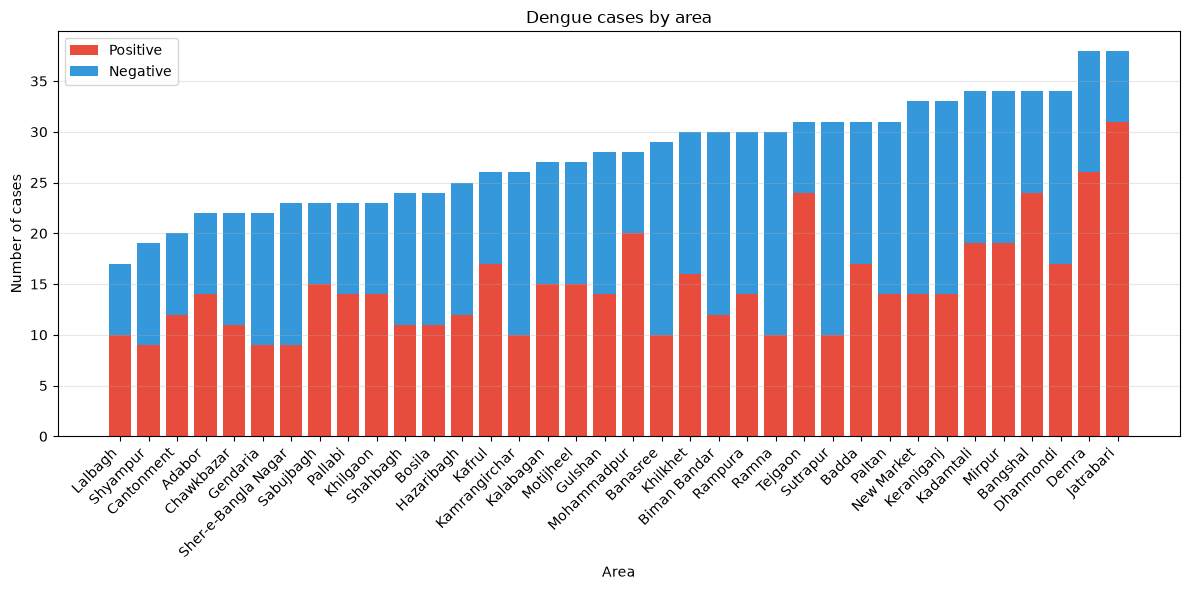

In [112]:
area_contamination_df = df[["Area", "Outcome"]].dropna().copy()
area_contamination_df = area_contamination_df.sort_values("Area")

area_contamination_df = area_contamination_df.groupby("Area").agg(
    total_cases=("Outcome", "size"),
    positive_cases=("Outcome", lambda s: (s == 1).sum()),
    negative_cases=("Outcome", lambda s: (s == 0).sum())
).reset_index()

area_contamination_df = area_contamination_df.sort_values("total_cases").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(area_contamination_df))
ax.bar(
    x,
    area_contamination_df["positive_cases"],
    label="Positive",
    color="#e74c3c",
    width=0.8,
)
ax.bar(
    x,
    area_contamination_df["negative_cases"],
    bottom=area_contamination_df["positive_cases"],
    label="Negative",
    color="#3498db",
    width=0.8,
)

ax.set_xticks(x)
ax.set_xticklabels(area_contamination_df["Area"], rotation=45, ha="right")
ax.set_title("Total Dengue Cases by Area")
ax.set_xlabel("Area")
ax.set_ylabel("Number of cases")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [114]:
area_contamination_df.shape[0]

36

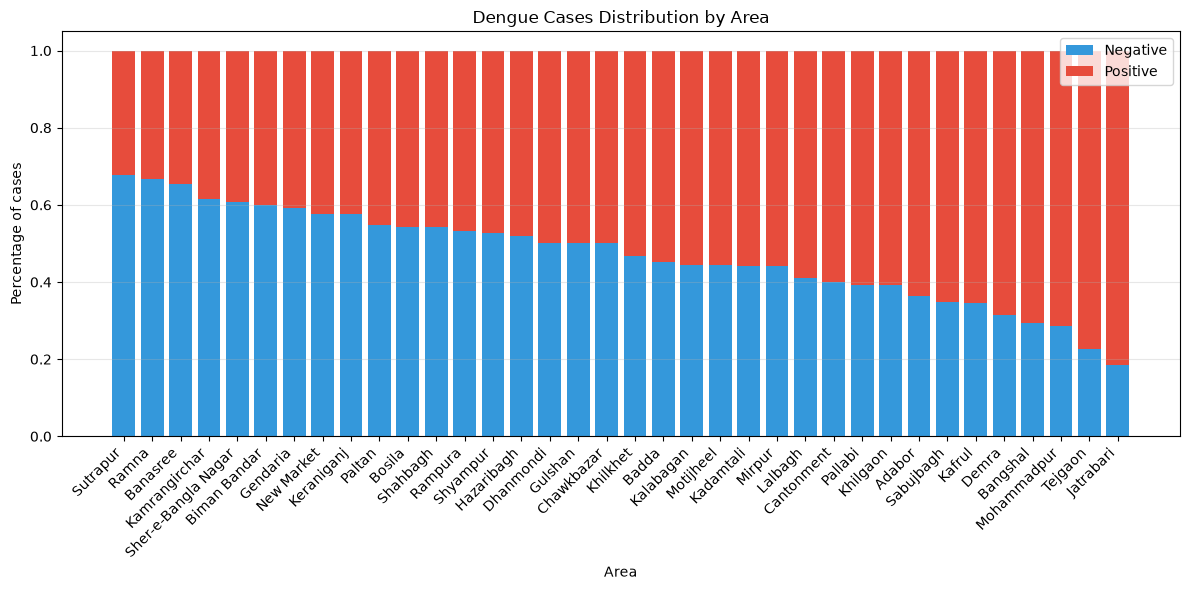

In [119]:
area_contamination_df = df[["Area", "Outcome"]].dropna().copy()
area_contamination_df = area_contamination_df.sort_values("Area")

area_contamination_df = (
    area_contamination_df.groupby("Area", as_index=False)
    .agg(
        total_cases=("Outcome", "size"),
        positive_cases=("Outcome", lambda s: int((s == 1).sum())),
        negative_cases=("Outcome", lambda s: int((s == 0).sum())),
    )
    .assign(
        positive_cases_perc=lambda d: d["positive_cases"] / d["total_cases"],
        negative_cases_perc=lambda d: d["negative_cases"] / d["total_cases"],
    )
    .sort_values("positive_cases_perc")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(area_contamination_df))
ax.bar(
    x,
    area_contamination_df["negative_cases_perc"],
    label="Negative",
    color="#3498db",
    width=0.8,
)
ax.bar(
    x,
    area_contamination_df["positive_cases_perc"],
    bottom=area_contamination_df["negative_cases_perc"],
    label="Positive",
    color="#e74c3c",
    width=0.8,
)

ax.set_xticks(x)
ax.set_xticklabels(area_contamination_df["Area"], rotation=45, ha="right")
ax.set_title("Dengue Cases Distribution by Area")
ax.set_xlabel("Area")
ax.set_ylabel("Percentage of cases")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

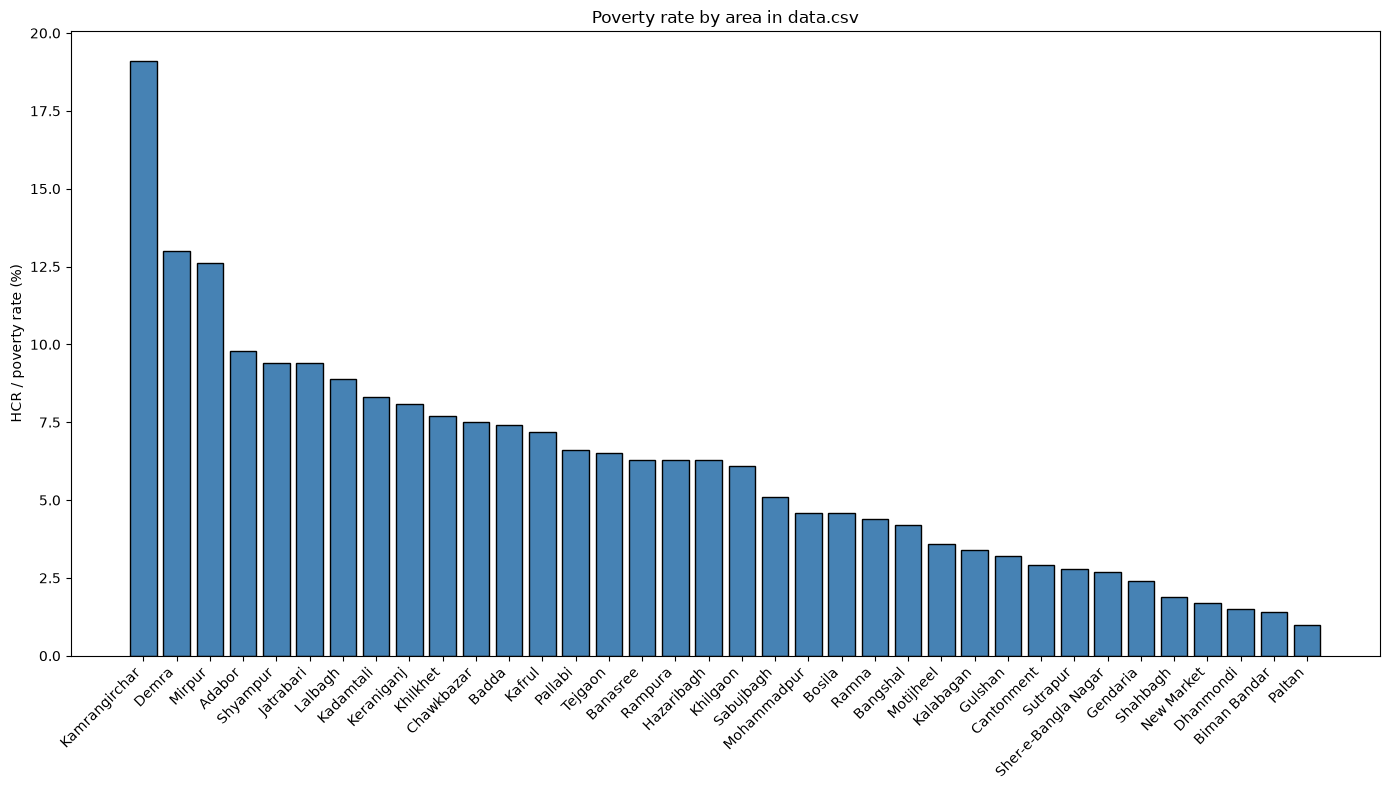

In [120]:
# Import area poverty table and plot HCR/poverty rate by area
import pandas as pd
import matplotlib.pyplot as plt

poverty_df = pd.read_csv('area_poverty_table.csv')
df = pd.read_csv('data.csv')

area_poverty = (
    df[['Area']]
    .drop_duplicates()
    .merge(poverty_df[['Area', 'HCR_upper_2022']], on='Area', how='left')
    .rename(columns={'HCR_upper_2022': 'HCR_poverty_rate'})
    .sort_values('HCR_poverty_rate', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(14, 8))
plt.bar(area_poverty['Area'], area_poverty['HCR_poverty_rate'], color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.ylabel('HCR / poverty rate (%)')
plt.title('Poverty rate by area in data.csv')
plt.tight_layout()
plt.show()


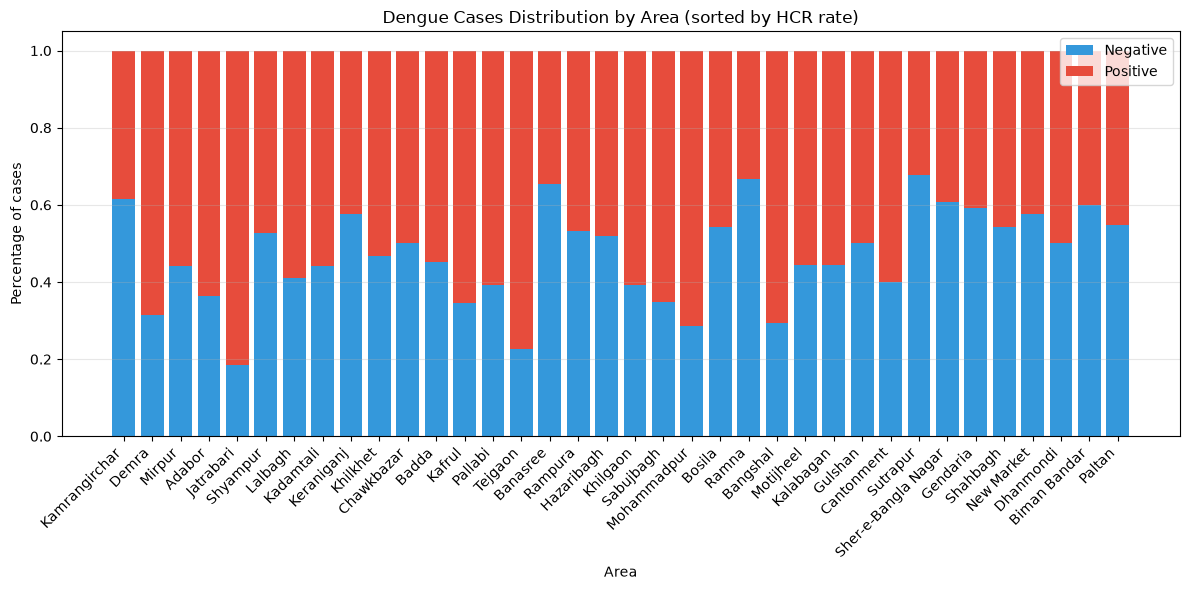

In [ ]:
poverty_df = pd.read_csv('area_poverty_table.csv')

area_hcr_df = (
    area_contamination_df
    .merge(poverty_df[['Area', 'HCR_upper_2022']], on='Area', how='left')
    .sort_values('HCR_upper_2022', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(area_hcr_df))
ax.bar(
    x,
    area_hcr_df["negative_cases_perc"],
    label="Negative",
    color="#3498db",
    width=0.8,
)
ax.bar(
    x,
    area_hcr_df["positive_cases_perc"],
    bottom=area_hcr_df["negative_cases_perc"],
    label="Positive",
    color="#e74c3c",
    width=0.8,
)

ax.set_xticks(x)
ax.set_xticklabels(area_hcr_df["Area"], rotation=45, ha="right")
ax.set_title("Dengue Cases Distribution by Area (sorted by HCR rate)")
ax.set_xlabel("Area")
ax.set_ylabel("Percentage of cases")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


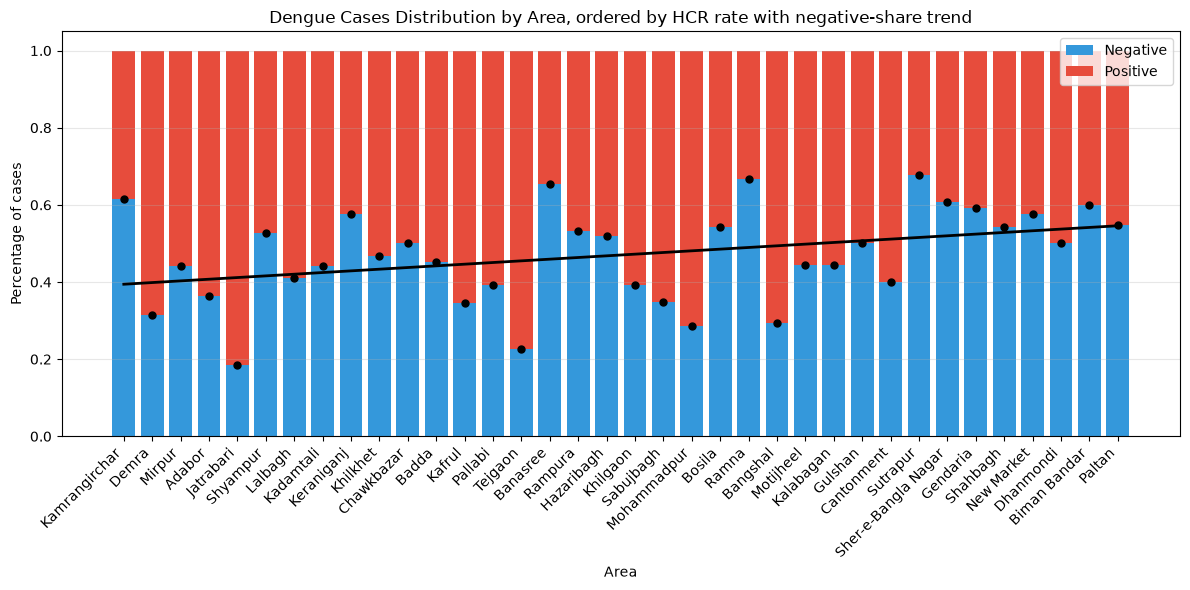

In [ ]:
poverty_df = pd.read_csv('area_poverty_table.csv')

area_hcr_df = (
    area_contamination_df
    .merge(poverty_df[['Area', 'HCR_upper_2022']], on='Area', how='left')
    .sort_values('HCR_upper_2022', ascending=False)
    .reset_index(drop=True)
    .assign(hcr_rank=lambda d: np.arange(len(d)))
)

fig, ax = plt.subplots(figsize=(12, 6))

x = area_hcr_df['hcr_rank'].to_numpy()
ax.bar(
    x,
    area_hcr_df['negative_cases_perc'],
    label='Negative',
    color='#3498db',
    width=0.8,
)
ax.bar(
    x,
    area_hcr_df['positive_cases_perc'],
    bottom=area_hcr_df['negative_cases_perc'],
    label='Positive',
    color='#e74c3c',
    width=0.8,
)

sns.regplot(
    data=area_hcr_df,
    x='hcr_rank',
    y='negative_cases_perc',
    ax=ax,
    scatter=False,
    color='black',
    line_kws={'linewidth': 2},
    ci=None,
)
ax.scatter(x, area_hcr_df['negative_cases_perc'], color='black', s=25, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(area_hcr_df['Area'], rotation=45, ha='right')
ax.set_title('Dengue Cases Distribution by Area, ordered by HCR rate with negative-share trend')
ax.set_xlabel('Area')
ax.set_ylabel('Percentage of cases')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


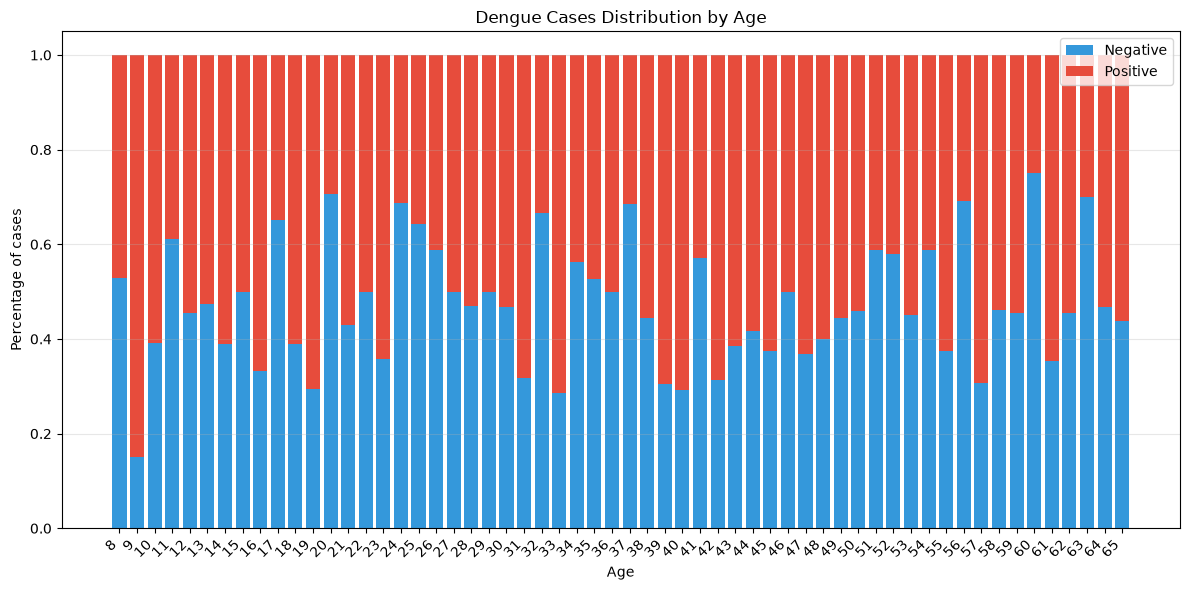

In [143]:
area_contamination_df = df[["Age", "Outcome"]].dropna().copy()
area_contamination_df = area_contamination_df.sort_values("Age")

area_contamination_df = (
    area_contamination_df.groupby("Age", as_index=False)
    .agg(
        total_cases=("Outcome", "size"),
        positive_cases=("Outcome", lambda s: int((s == 1).sum())),
        negative_cases=("Outcome", lambda s: int((s == 0).sum())),
    )
    .assign(
        positive_cases_perc=lambda d: d["positive_cases"] / d["total_cases"],
        negative_cases_perc=lambda d: d["negative_cases"] / d["total_cases"],
    )
    .sort_values("Age")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(area_contamination_df))
ax.bar(
    x,
    area_contamination_df["negative_cases_perc"],
    label="Negative",
    color="#3498db",
    width=0.8,
)
ax.bar(
    x,
    area_contamination_df["positive_cases_perc"],
    bottom=area_contamination_df["negative_cases_perc"],
    label="Positive",
    color="#e74c3c",
    width=0.8,
)

ax.set_xticks(x)
ax.set_xticklabels(area_contamination_df["Age"], rotation=45, ha="right")
ax.set_title("Dengue Cases Distribution by Age")
ax.set_xlabel("Age")
ax.set_ylabel("Percentage of cases")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

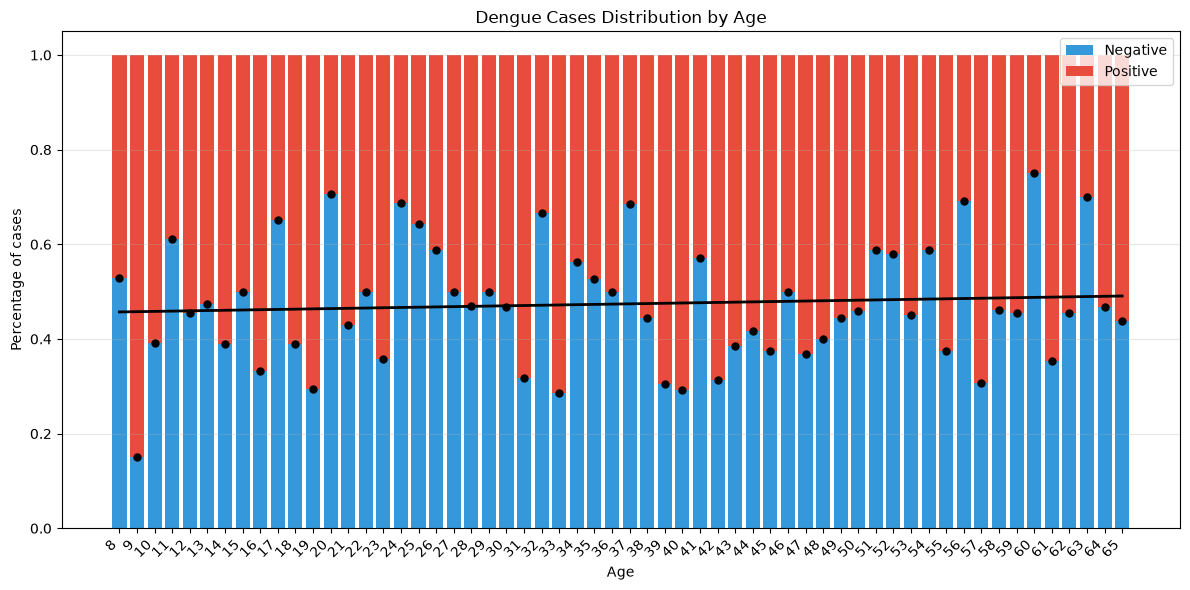

Negative-case trend slope: 0.000591
Regression equation: y = 0.000591 * x + 0.457094


In [149]:
age_contamination_df = df[["Age", "Outcome"]].dropna().copy()
age_contamination_df = age_contamination_df.sort_values("Age")

age_contamination_df = (
    age_contamination_df.groupby("Age", as_index=False)
    .agg(
        total_cases=("Outcome", "size"),
        positive_cases=("Outcome", lambda s: int((s == 1).sum())),
        negative_cases=("Outcome", lambda s: int((s == 0).sum())),
    )
    .assign(
        positive_cases_perc=lambda d: d["positive_cases"] / d["total_cases"],
        negative_cases_perc=lambda d: d["negative_cases"] / d["total_cases"],
    )
    .sort_values("Age")
    .reset_index(drop=True)
    .assign(age_rank=lambda d: np.arange(len(d)))
)

fig, ax = plt.subplots(figsize=(12, 6))

x = age_contamination_df["age_rank"].to_numpy()
ax.bar(
    x,
    age_contamination_df["negative_cases_perc"],
    label="Negative",
    color="#3498db",
    width=0.8,
)
ax.bar(
    x,
    age_contamination_df["positive_cases_perc"],
    bottom=age_contamination_df["negative_cases_perc"],
    label="Positive",
    color="#e74c3c",
    width=0.8,
)

# Fit and print the regression slope for the negative percentage trend
model = np.polyfit(age_contamination_df['age_rank'], age_contamination_df['negative_cases_perc'], 1)
slope = model[0]
intercept = model[1]

sns.regplot(
    data=age_contamination_df,
    x='age_rank',
    y='negative_cases_perc',
    ax=ax,
    scatter=False,
    color='black',
    line_kws={'linewidth': 2},
    ci=None,
)
ax.scatter(x, age_contamination_df['negative_cases_perc'], color='black', s=25, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(age_contamination_df["Age"], rotation=45, ha="right")
ax.set_title("Dengue Cases Distribution by Age")
ax.set_xlabel("Age")
ax.set_ylabel("Percentage of cases")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"Negative-case trend slope: {slope:.6f}")
print(f"Regression equation: y = {slope:.6f} * x + {intercept:.6f}")

Gender x Outcome counts
Outcome  Negative  Positive
Gender                     
Male          224       252
Female        243       281


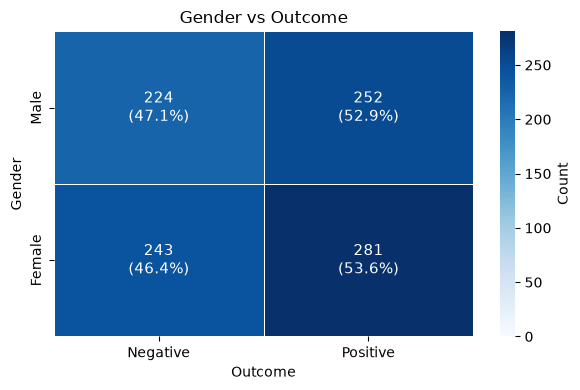

In [152]:
# Gender x Outcome confusion-style matrix
gender_outcome = (
    df[["Gender", "Outcome"]]
    .dropna()
    .assign(Outcome=lambda d: d["Outcome"].astype(int))
    .groupby(["Gender", "Outcome"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Negative", 1: "Positive"})
    .reindex(index=["Male", "Female"], fill_value=0)
)

gender_totals = gender_outcome.sum(axis=1)
gender_outcome_pct = gender_outcome.div(gender_totals, axis=0) * 100

gender_outcome = gender_outcome[["Negative", "Positive"]]

gender_labels = (
    gender_outcome.astype(str)
    + "\n("
    + gender_outcome_pct.round(1).astype(str)
    + "%)"
)

print("Gender x Outcome counts")
print(gender_outcome)

plt.figure(figsize=(6, 4))
ax = sns.heatmap(
    gender_outcome,
    annot=gender_labels.values,
    fmt="",
    cmap="Blues",
    cbar_kws={"label": "Count"},
    linewidths=0.5,
    linecolor="white",
    vmin=0,
    annot_kws={"fontsize": 11},
)
ax.set_title("Gender vs Outcome")
ax.set_xlabel("Outcome")
ax.set_ylabel("Gender")
plt.tight_layout()
plt.show()


AreaType x Outcome counts
Outcome      Negative  Positive
AreaType                       
Developed         242       257
Undeveloped       223       276


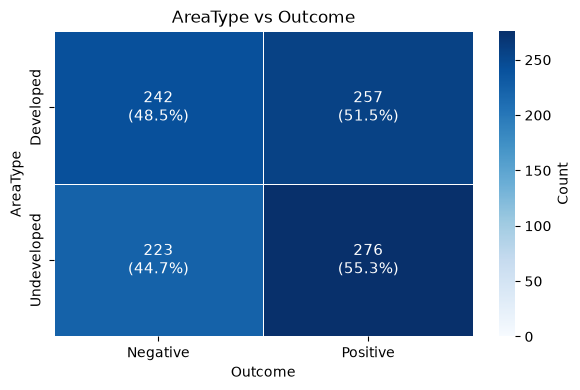

In [154]:
# AreaType x Outcome confusion-style matrix
area_type_outcome = (
    df[["AreaType", "Outcome"]]
    .dropna()
    .assign(Outcome=lambda d: d["Outcome"].astype(int))
    .groupby(["AreaType", "Outcome"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Negative", 1: "Positive"})
    .reindex(index=["Developed", "Undeveloped"], fill_value=0)
)

area_type_totals = area_type_outcome.sum(axis=1)
area_type_outcome_pct = area_type_outcome.div(area_type_totals, axis=0) * 100

area_type_outcome = area_type_outcome[["Negative", "Positive"]]

area_type_labels = (
    area_type_outcome.astype(str)
    + "\n("
    + area_type_outcome_pct.round(1).astype(str)
    + "%)"
)

print("AreaType x Outcome counts")
print(area_type_outcome)

plt.figure(figsize=(6, 4))
ax = sns.heatmap(
    area_type_outcome,
    annot=area_type_labels.values,
    fmt="",
    cmap="Blues",
    cbar_kws={"label": "Count"},
    linewidths=0.5,
    linecolor="white",
    vmin=0,
    annot_kws={"fontsize": 11},
)
ax.set_title("AreaType vs Outcome")
ax.set_xlabel("Outcome")
ax.set_ylabel("AreaType")
plt.tight_layout()
plt.show()


HouseType x Outcome counts
Outcome    Negative  Positive
HouseType                    
Building        163       191
Tinshed         144       173
Other           160       169


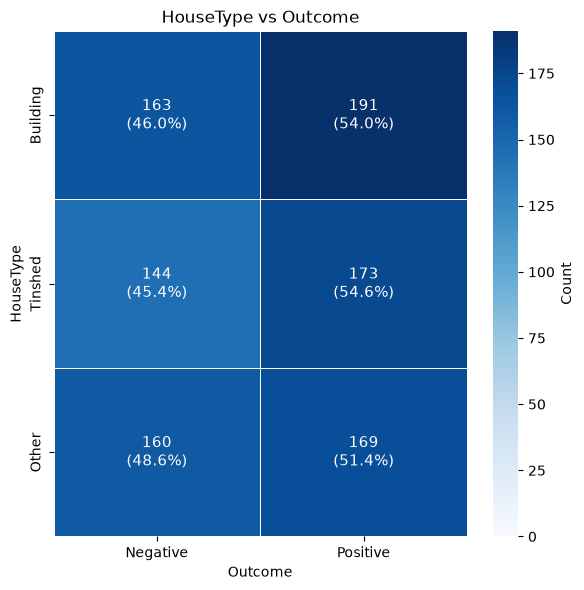

In [157]:
# HouseType x Outcome confusion-style matrix
house_type_outcome = (
    df[["HouseType", "Outcome"]]
    .dropna()
    .assign(Outcome=lambda d: d["Outcome"].astype(int))
    .groupby(["HouseType", "Outcome"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Negative", 1: "Positive"})
    .reindex(index=["Building", "Tinshed", "Other"], fill_value=0)
)

house_type_totals = house_type_outcome.sum(axis=1)
house_type_outcome_pct = house_type_outcome.div(house_type_totals, axis=0) * 100

house_type_outcome = house_type_outcome[["Negative", "Positive"]]

house_type_labels = (
    house_type_outcome.astype(str)
    + "\n("
    + house_type_outcome_pct.round(1).astype(str)
    + "%)"
)

print("HouseType x Outcome counts")
print(house_type_outcome)

plt.figure(figsize=(6, 6))
ax = sns.heatmap(
    house_type_outcome,
    annot=house_type_labels.values,
    fmt="",
    cmap="Blues",
    cbar_kws={"label": "Count"},
    linewidths=0.5,
    linecolor="white",
    vmin=0,
    annot_kws={"fontsize": 11},
)
ax.set_title("HouseType vs Outcome")
ax.set_xlabel("Outcome")
ax.set_ylabel("HouseType")
plt.tight_layout()
plt.show()


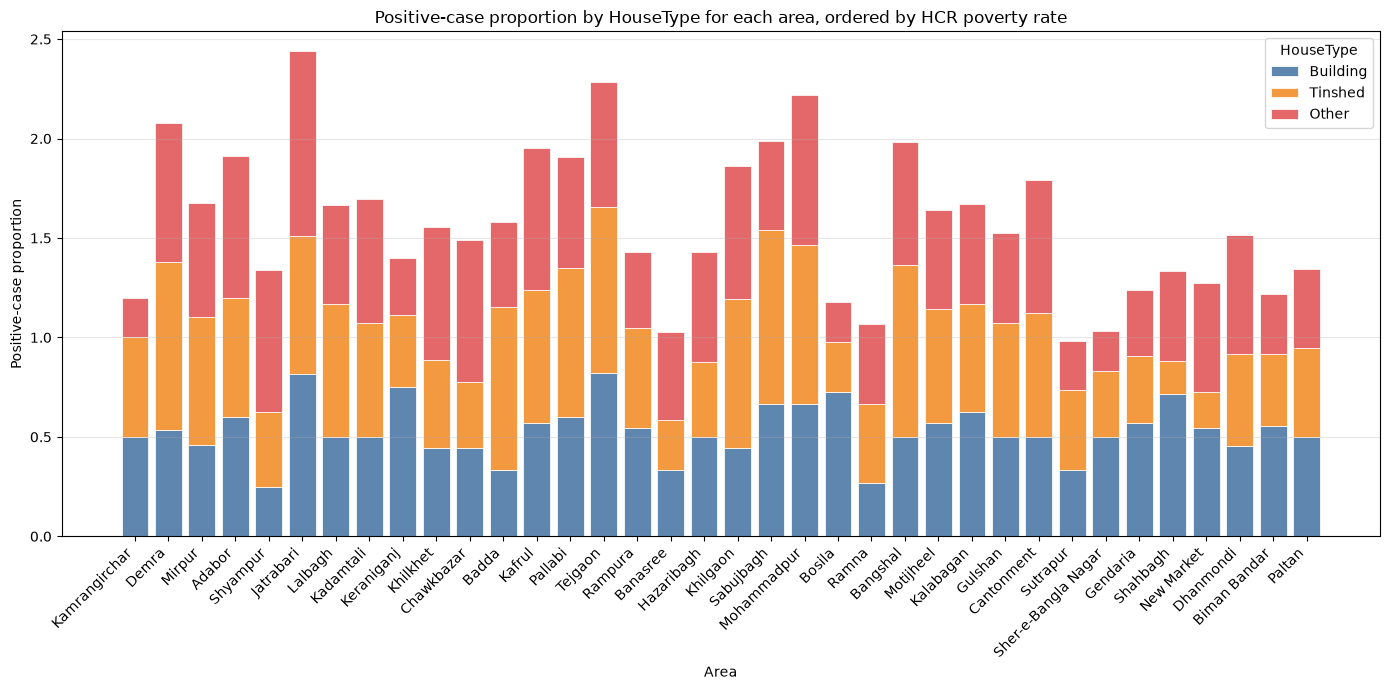

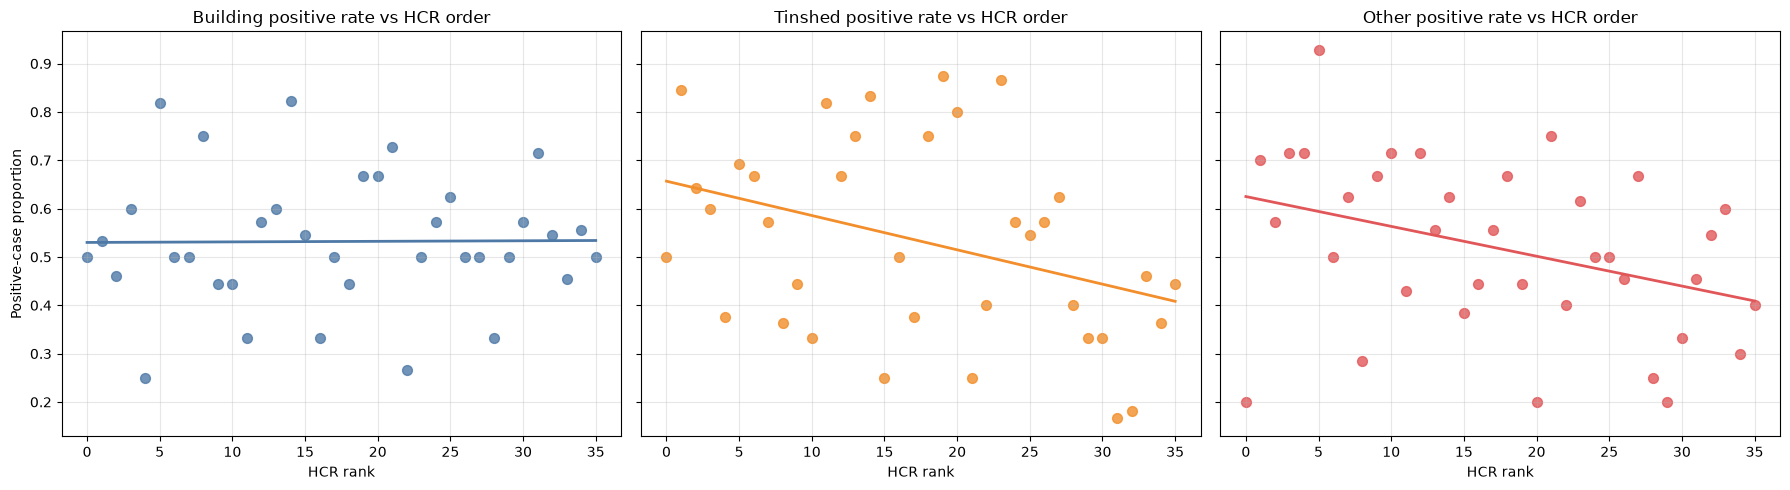

In [164]:
# Stacked HouseType bar plot for each area, ordered by HCR poverty rate
poverty_df = pd.read_csv('area_poverty_table.csv')

house_area_df = (
    df[['Area', 'HouseType', 'Outcome']]
    .dropna()
    .copy()
    .assign(Outcome=lambda d: d['Outcome'].astype(int))
    .loc[lambda d: d['HouseType'].isin(['Building', 'Tinshed', 'Other'])]
)

house_area_summary = (
    house_area_df.groupby(['Area', 'HouseType'], as_index=False)
    .agg(
        total_cases=('Outcome', 'size'),
        positive_cases=('Outcome', lambda s: int((s == 1).sum())),
    )
    .assign(positive_rate=lambda d: d['positive_cases'] / d['total_cases'])
)

area_house_type_plot = (
    house_area_summary
    .merge(poverty_df[['Area', 'HCR_upper_2022']], on='Area', how='left')
    .sort_values('HCR_upper_2022', ascending=False)
    .reset_index(drop=True)
    .assign(hcr_rank=lambda d: np.arange(len(d)))
)

house_types = ['Building', 'Tinshed', 'Other']
areas_order = area_house_type_plot['Area'].drop_duplicates().tolist()
plot_pivot = (
    area_house_type_plot
    .pivot(index='Area', columns='HouseType', values='positive_rate')
    .reindex(index=areas_order, columns=house_types)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(plot_pivot))
bottom = np.zeros(len(plot_pivot))
colors = {'Building': '#4e79a7', 'Tinshed': '#f28e2b', 'Other': '#e15759'}

for house_type in house_types:
    values = plot_pivot[house_type].to_numpy()
    ax.bar(
        x,
        values,
        width=0.8,
        bottom=bottom,
        color=colors[house_type],
        edgecolor='white',
        linewidth=0.6,
        label=house_type,
        alpha=0.9,
    )
    bottom = bottom + values

ax.set_xticks(x)
ax.set_xticklabels(plot_pivot.index, rotation=45, ha='right')
ax.set_title('Positive-case proportion by HouseType for each area, ordered by HCR poverty rate')
ax.set_xlabel('Area')
ax.set_ylabel('Positive-case proportion')
ax.set_ylim(0, max(1.05, plot_pivot.sum(axis=1).max() + 0.1))
ax.grid(axis='y', alpha=0.3)
ax.legend(title='HouseType')
plt.tight_layout()
plt.show()

# Separate regression/scatter view for each HouseType against HCR order
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = {'Building': '#4e79a7', 'Tinshed': '#f28e2b', 'Other': '#e15759'}

for ax, house_type in zip(axes, house_types):
    reg_df = area_house_type_plot[area_house_type_plot['HouseType'] == house_type].copy()
    reg_df = reg_df.sort_values('HCR_upper_2022', ascending=False).reset_index(drop=True)
    reg_df['hcr_rank'] = np.arange(len(reg_df))

    sns.regplot(
        data=reg_df,
        x='hcr_rank',
        y='positive_rate',
        ax=ax,
        scatter=False,
        color=colors[house_type],
        line_kws={'linewidth': 2},
        ci=None,
    )
    ax.scatter(reg_df['hcr_rank'], reg_df['positive_rate'], color=colors[house_type], s=50, alpha=0.8)

    ax.set_title(f'{house_type} positive rate vs HCR order')
    ax.set_xlabel('HCR rank')
    ax.set_ylabel('Positive-case proportion' if ax is axes[0] else '')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
